# Importaciones

In [25]:
import pandas as pd
import numpy as np
import sklearn as sk
import statsmodels.api as sm
import matplotlib.pyplot as plt
plt.style.use('bmh')

# Datos de salud

In [26]:
data = pd.read_csv('/content/fetal_health.csv')

In [27]:
data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


### Cambio de tipo de datos

In [28]:
data['baseline value'] = data['baseline value'].astype(int)
data['abnormal_short_term_variability'] = data['abnormal_short_term_variability'].astype(int)
data['histogram_width'] = data['histogram_width'].astype(int)
data['histogram_min'] = data['histogram_min'].astype(int)
data['histogram_max'] = data['histogram_max'].astype(int)
data['histogram_number_of_peaks'] = data['histogram_number_of_peaks'].astype(int)
data['histogram_number_of_zeroes'] = data['histogram_number_of_zeroes'].astype(int)
data['histogram_mode'] = data['histogram_mode'].astype(int)
data['fetal_health'] = data['fetal_health'].astype(int)

### Análisis univariado

In [29]:
data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [30]:
print(len(data[data['fetal_health']==1]))
print(len(data[data['fetal_health']==2]))
print(len(data[data['fetal_health']==3]))

1655
295
176


Pasamos de 3 clases de clasificación a 2. Agrupamos los valores 2 y 3 de clasificación.
Además, convertimos la variable *target* a [0,1] para evitar errores.

In [31]:
data['fetal_health'] = data['fetal_health'].apply(lambda x: 0 if x == 1 else 1)

In [32]:
data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,0.221543
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.415383
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,0.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,0.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,0.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,0.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,1.000000


In [33]:
print(len(data[data['fetal_health']==0]))
print(len(data[data['fetal_health']==1]))

1655
471


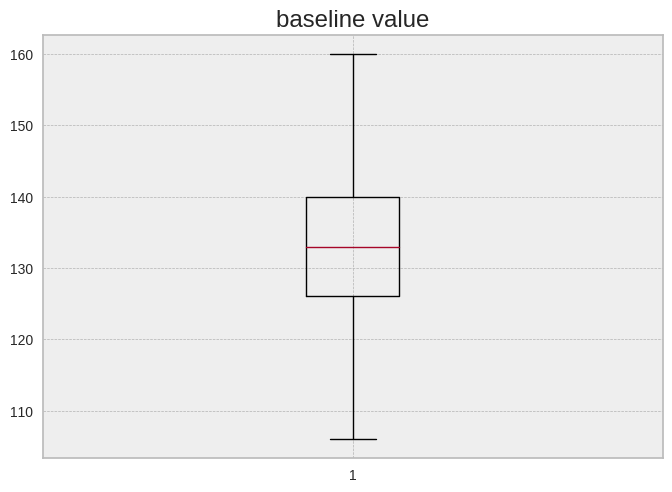

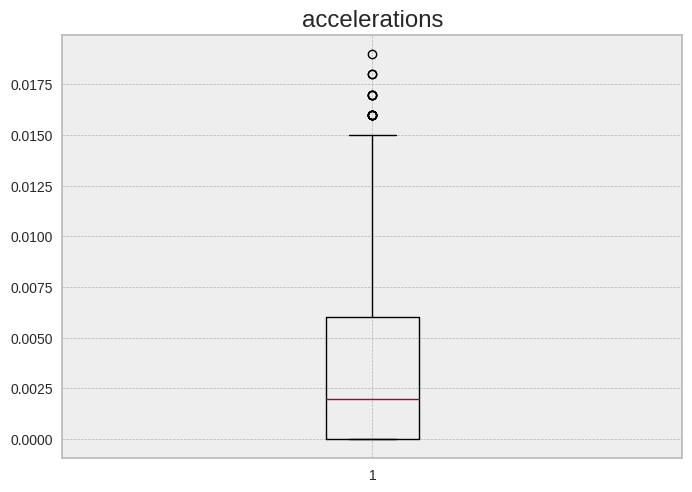

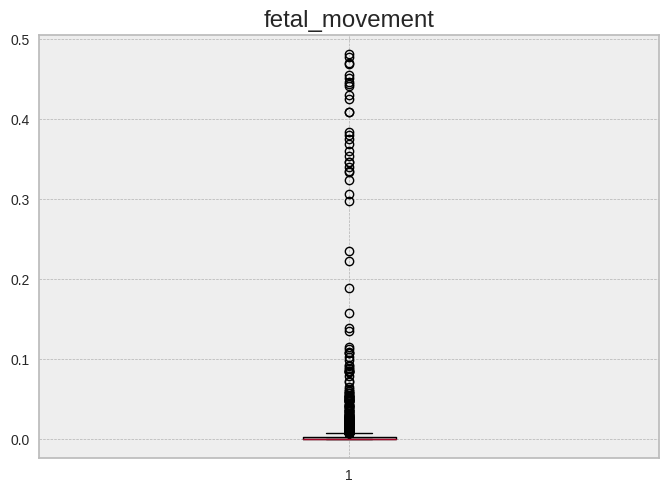

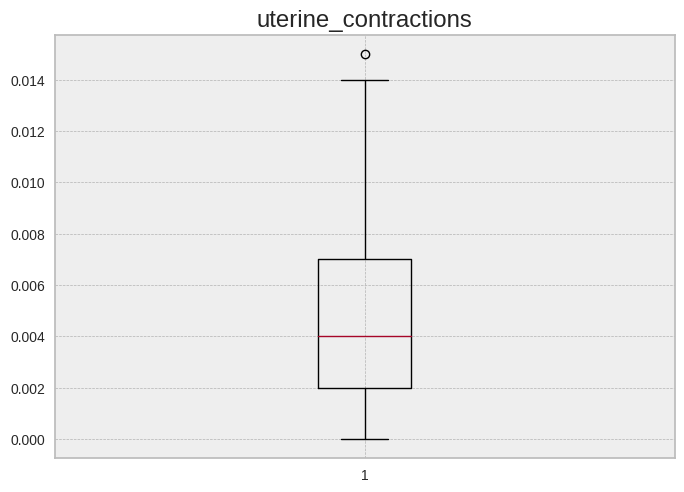

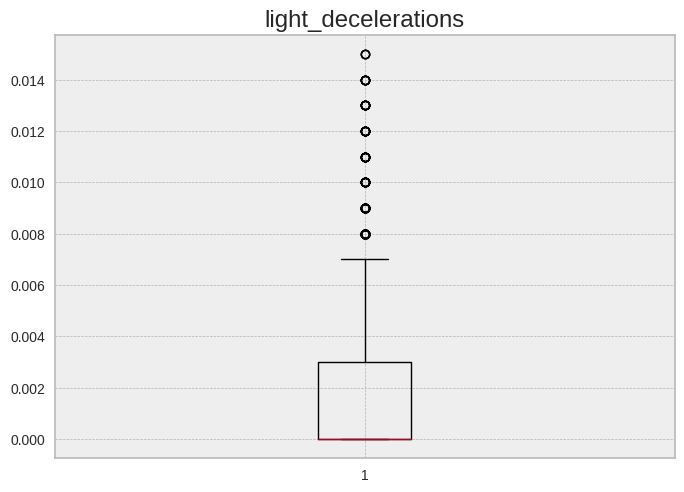

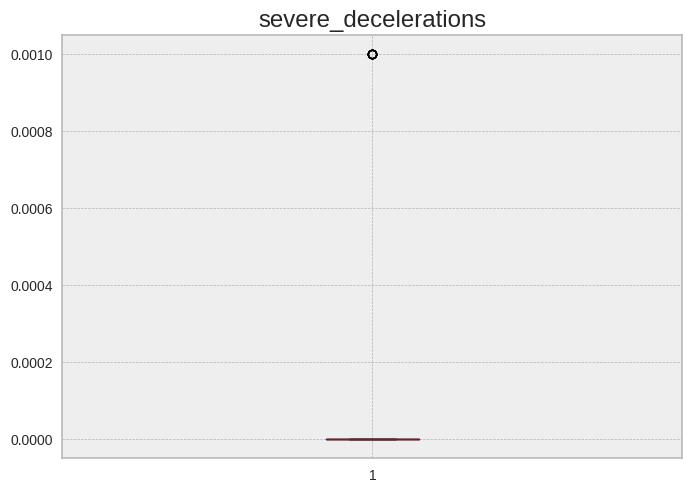

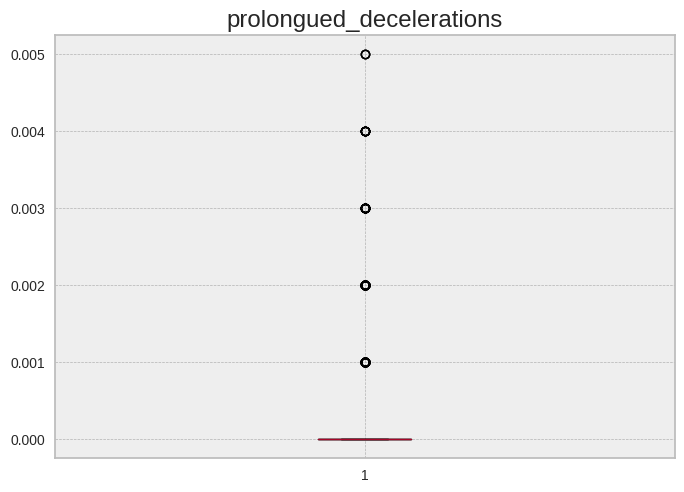

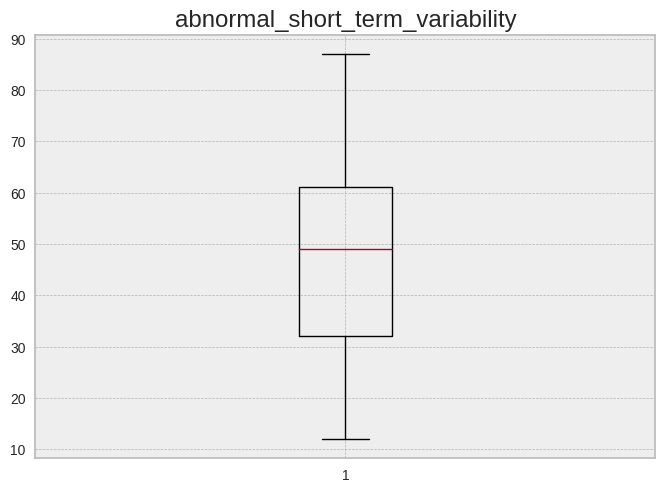

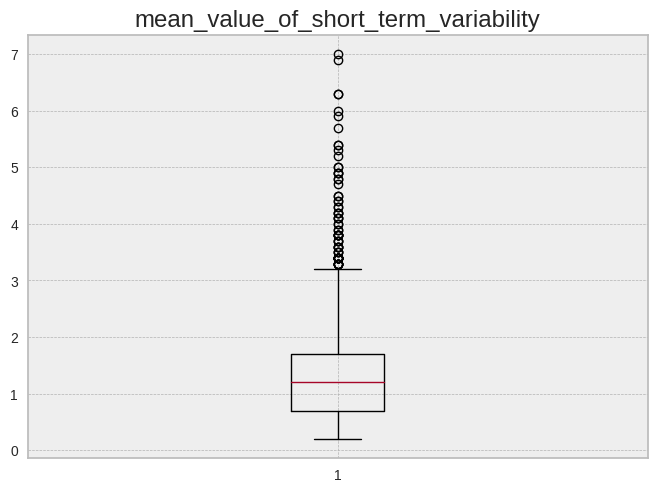

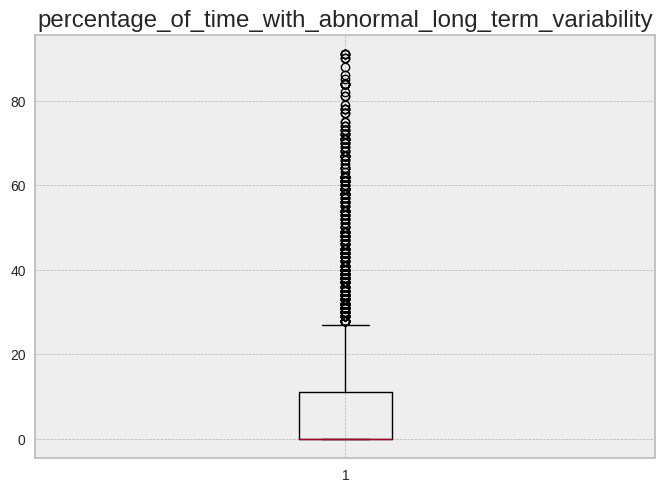

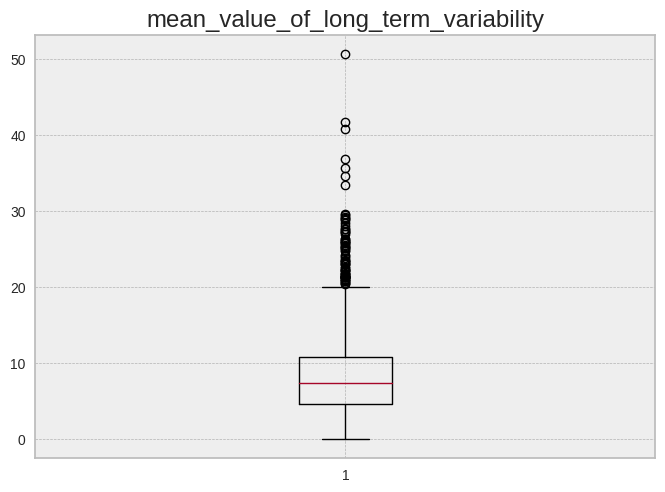

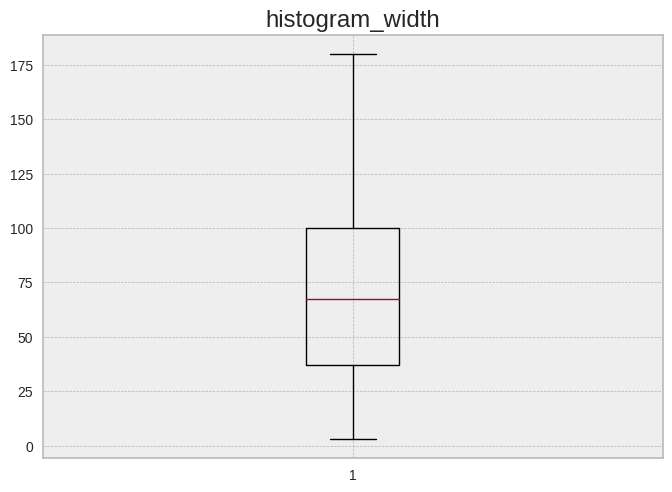

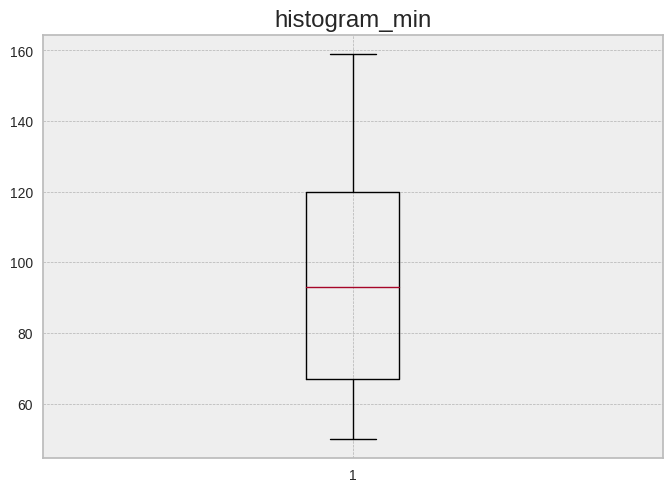

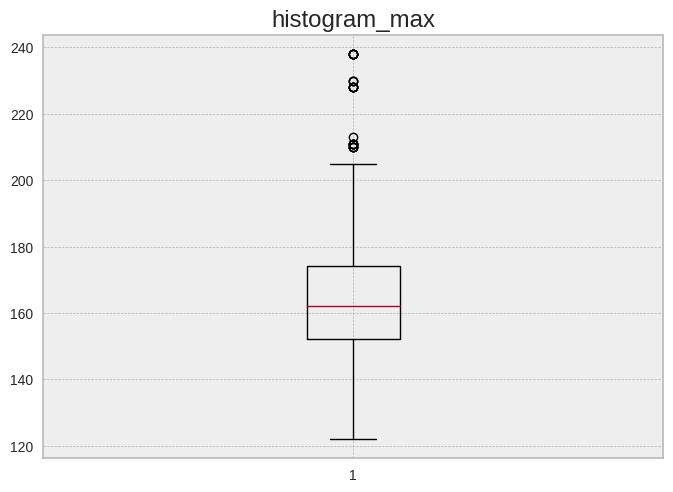

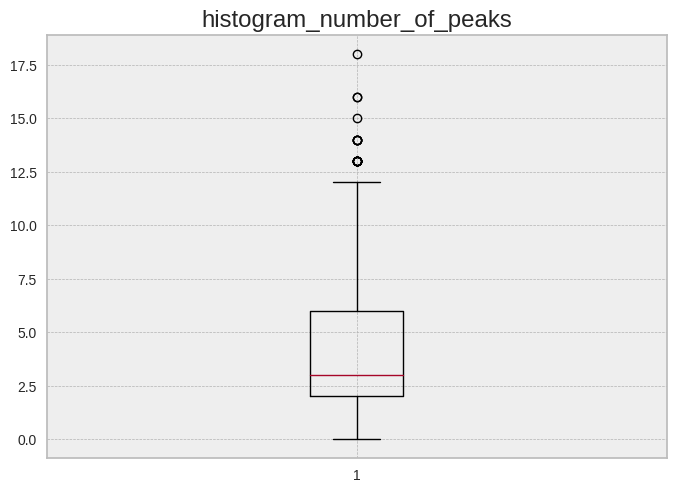

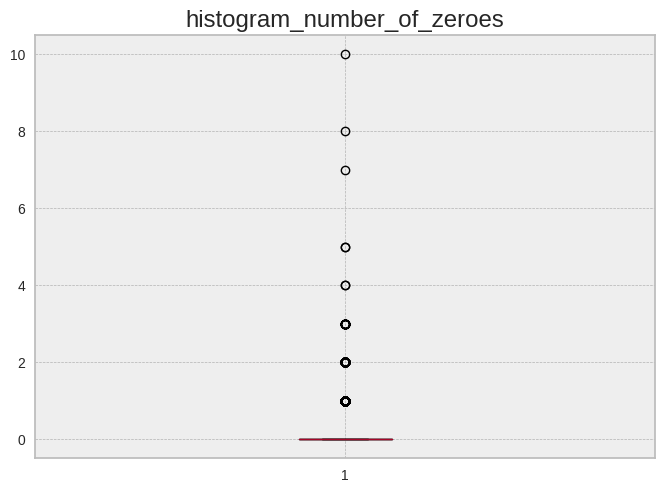

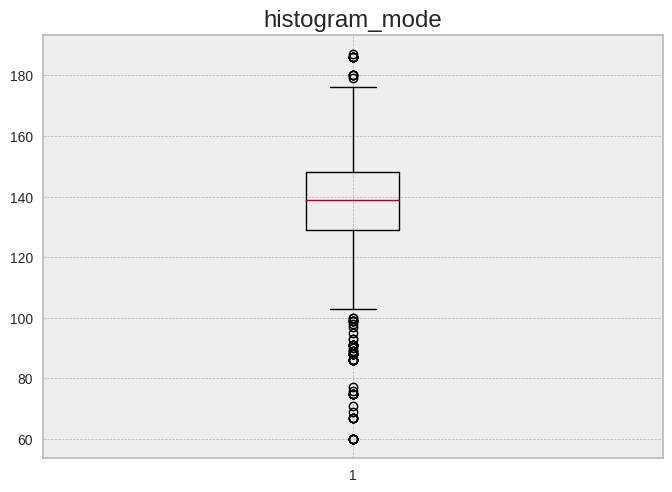

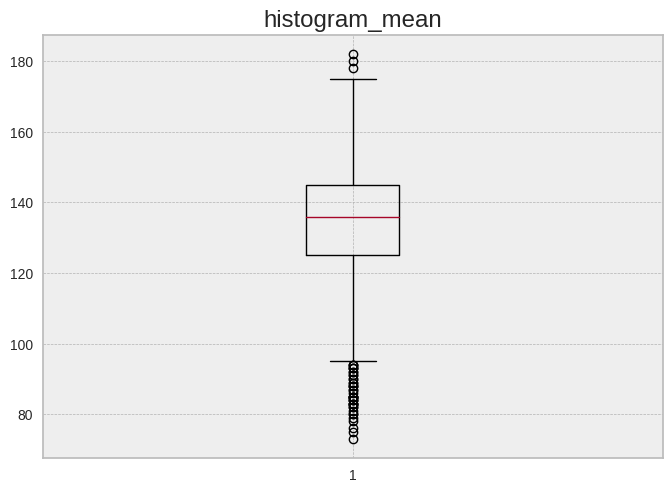

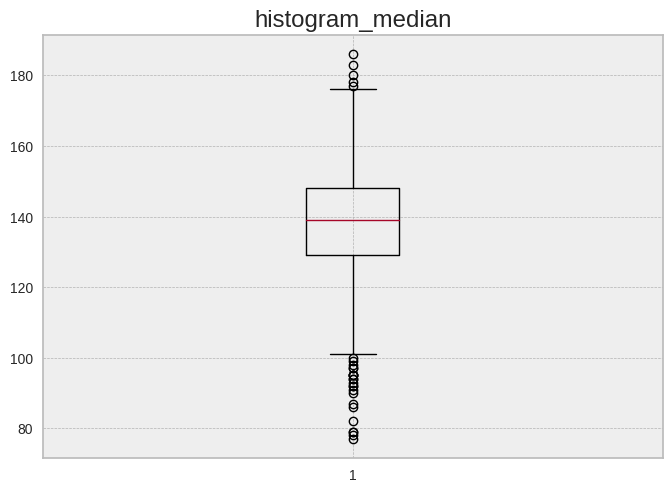

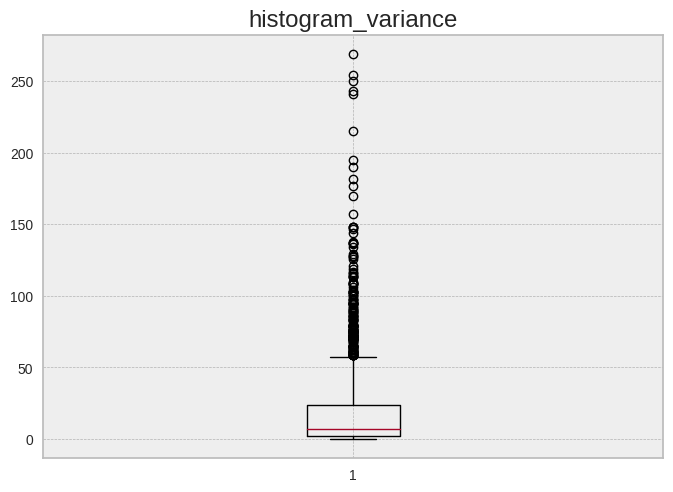

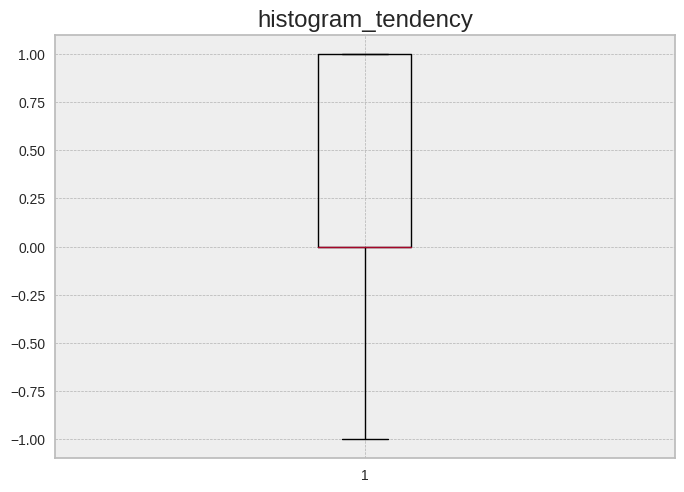

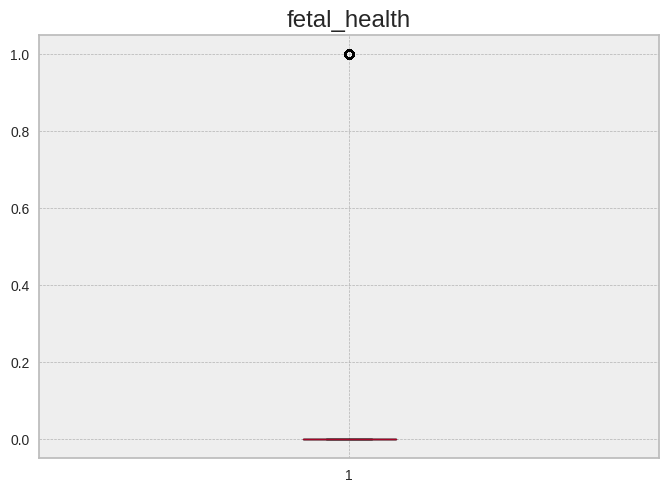

In [34]:
for col in data.columns:
  fig, ax = plt.subplots()
  ax.boxplot(data[col])
  ax.set_title(col)
  plt.show()

Detectamos outliers y los tratamos de maneras diferentes:

In [35]:
data[data['uterine_contractions'] > 0.014]

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
1164,131,0.011,0.0,0.015,0.0,0.0,0.0,26,1.5,0.0,...,109,170,2,1,155,151.0,154.0,11.0,1.0,0


In [36]:
i = data[data['uterine_contractions'] > 0.014].index
data = data.drop(i)

In [37]:
data[data['mean_value_of_short_term_variability'] > 6.5]

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
31,132,0.000,0.112,0.004,0.014,0.0,0.0,22,6.9,0.0,...,50,199,10,0,123,112.0,115.0,66.0,0.0,0
48,122,0.003,0.006,0.006,0.006,0.0,0.0,22,7.0,0.0,...,50,199,7,0,129,118.0,124.0,75.0,0.0,0


In [38]:
i = data[data['mean_value_of_short_term_variability'] > 6.5].index
data = data.drop(i)

In [39]:
data[data['mean_value_of_long_term_variability'] > 45]

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
166,134,0.003,0.007,0.001,0.0,0.0,0.0,53,3.7,0.0,...,54,184,1,0,136,135.0,139.0,25.0,0.0,0


In [40]:
i = data[data['mean_value_of_long_term_variability'] > 45].index
data = data.drop(i)

In [41]:
data[data['histogram_variance'] > 200]

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
6,134,0.001,0.000,0.013,0.008,0.0,0.003,29,6.3,0.0,...,50,200,6,3,71,107.0,106.0,215.0,0.0,1
1905,130,0.001,0.000,0.012,0.013,0.0,0.000,62,2.0,0.0,...,50,177,7,0,60,95.0,112.0,269.0,0.0,1
1906,130,0.001,0.001,0.012,0.010,0.0,0.001,62,2.2,0.0,...,50,211,9,0,60,89.0,113.0,250.0,0.0,1
1907,130,0.002,0.002,0.009,0.009,0.0,0.002,63,2.3,0.0,...,50,211,5,0,60,88.0,113.0,254.0,-1.0,1
1908,130,0.002,0.002,0.008,0.008,0.0,0.002,64,2.4,0.0,...,50,211,8,0,60,85.0,112.0,243.0,-1.0,1
1909,130,0.002,0.002,0.008,0.008,0.0,0.002,64,2.5,0.0,...,50,211,7,0,60,83.0,114.0,241.0,-1.0,1


In [42]:
data['histogram_variance'] = np.log(data['histogram_variance']).replace(-np.inf, 0)

In [43]:
data['histogram_variance'].describe()

,histogram_variance
count,2122.000000
mean,1.974502
std,1.450272
min,0.000000
25%,0.693147
50%,1.945910
75%,3.178054
max,5.594711


In [44]:
data[data['histogram_variance'] == min(data['histogram_variance'])]

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
9,122,0.000,0.000,0.003,0.000,0.0,0.0,86,0.3,6.0,...,62,130,1,0,122,122.0,123.0,0.0,1.0,1
23,128,0.000,0.000,0.000,0.000,0.0,0.0,80,0.5,0.0,...,114,130,0,0,126,124.0,125.0,0.0,1.0,1
24,128,0.000,0.000,0.003,0.000,0.0,0.0,86,0.3,79.0,...,114,130,0,0,128,126.0,129.0,0.0,1.0,1
25,124,0.000,0.000,0.000,0.000,0.0,0.0,86,0.3,72.0,...,118,130,1,0,124,124.0,125.0,0.0,0.0,1
26,124,0.000,0.000,0.000,0.000,0.0,0.0,86,0.4,14.0,...,122,146,1,0,126,126.0,127.0,0.0,-1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,140,0.000,0.000,0.006,0.000,0.0,0.0,83,0.2,48.0,...,132,152,2,0,145,145.0,146.0,0.0,0.0,0
2116,140,0.004,0.000,0.004,0.000,0.0,0.0,80,0.2,36.0,...,140,158,1,0,147,148.0,149.0,0.0,0.0,0
2117,140,0.000,0.000,0.008,0.000,0.0,0.0,79,0.3,20.0,...,124,150,1,0,144,143.0,145.0,0.0,1.0,0
2119,140,0.000,0.000,0.007,0.001,0.0,0.0,79,0.6,27.0,...,124,150,1,0,144,141.0,145.0,0.0,1.0,0


Volvemos a observar los *boxplots* una vez se han tratado los *outliers*

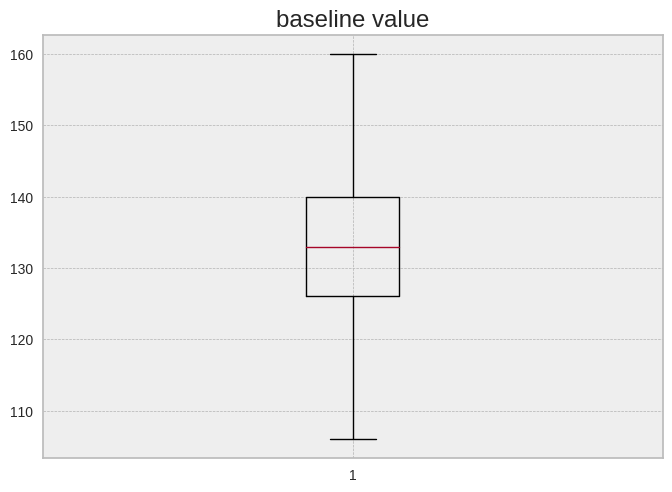

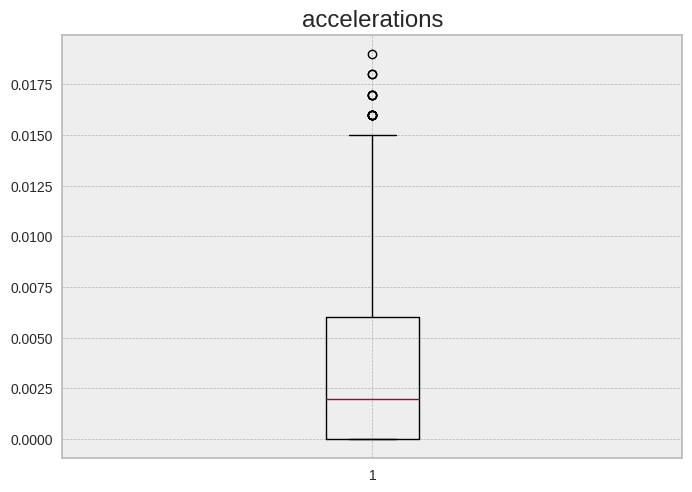

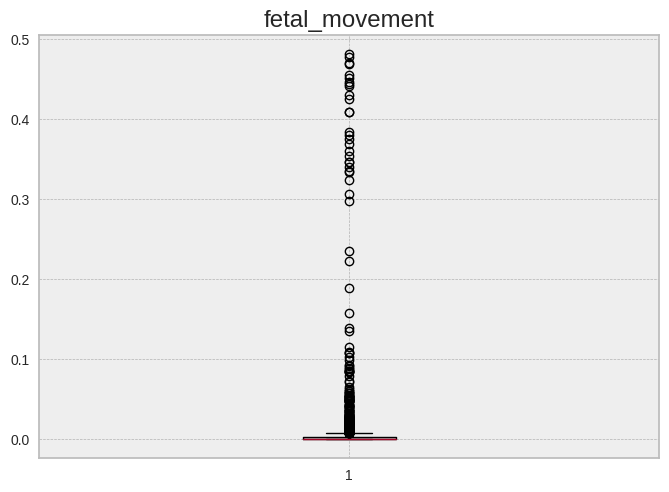

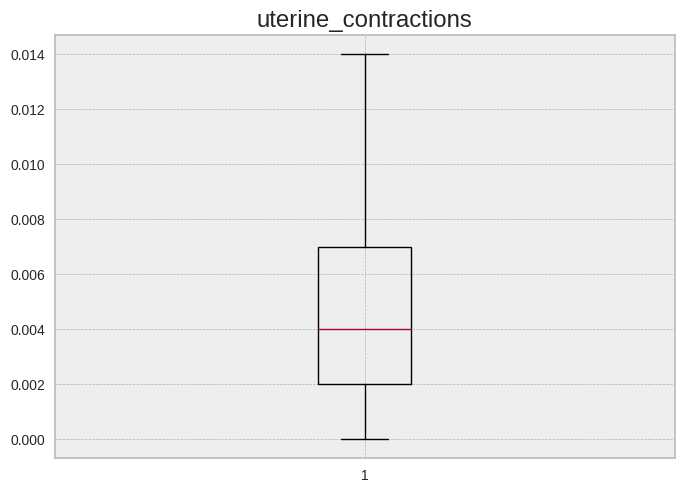

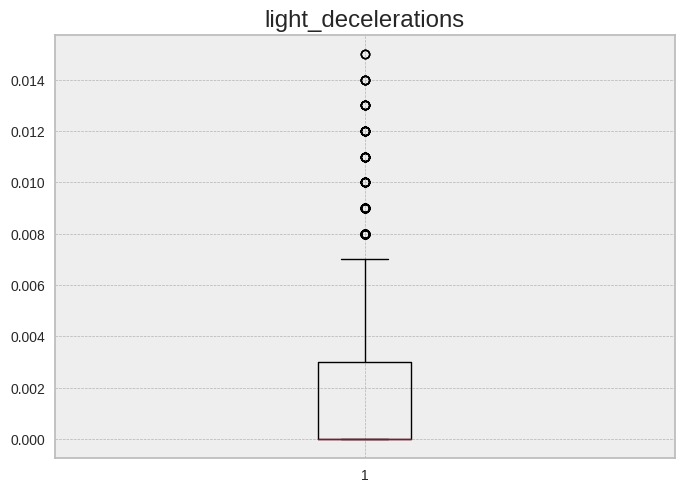

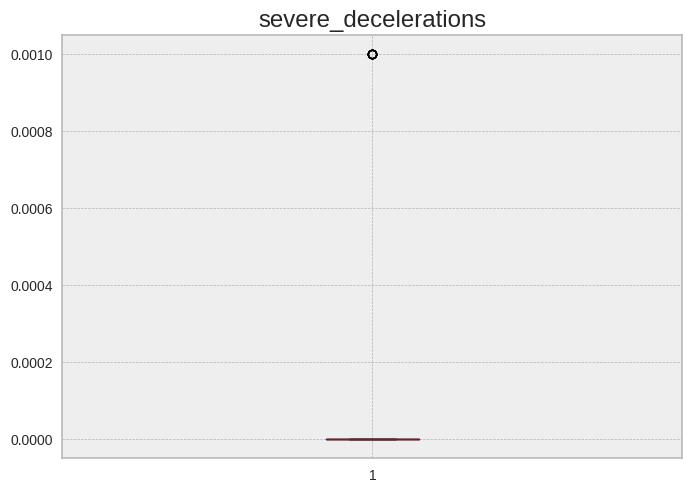

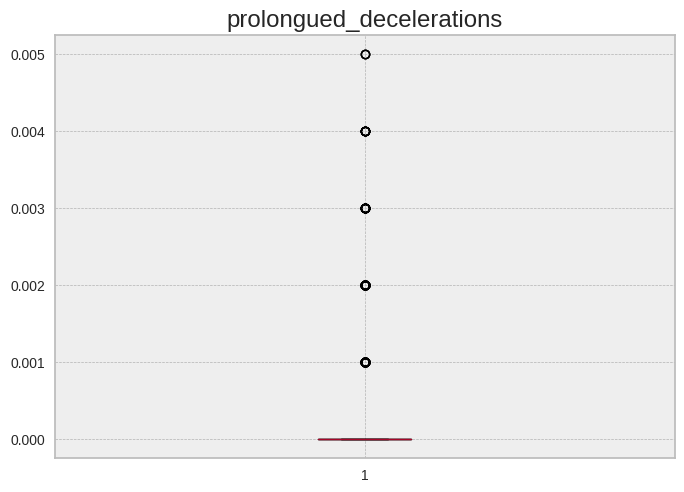

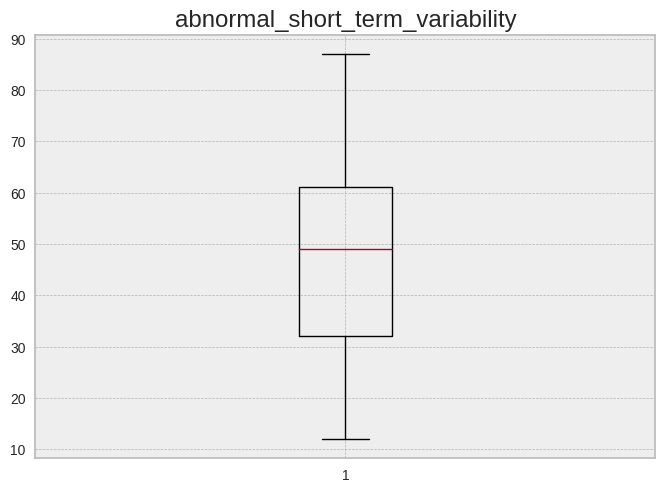

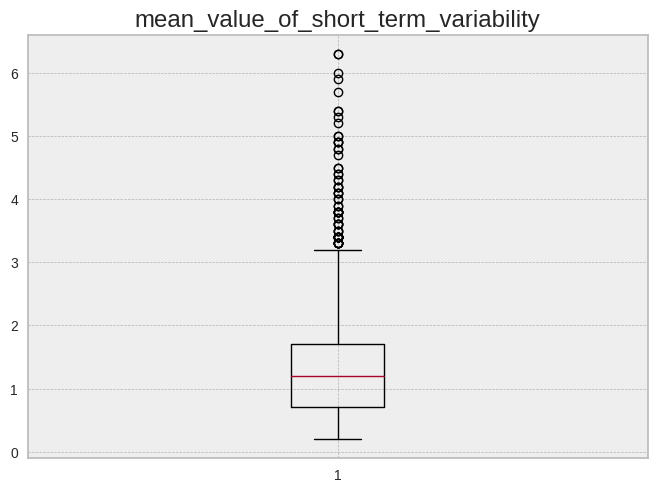

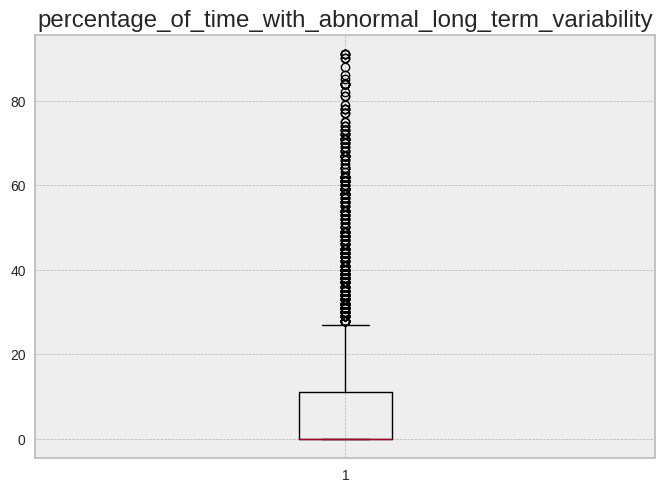

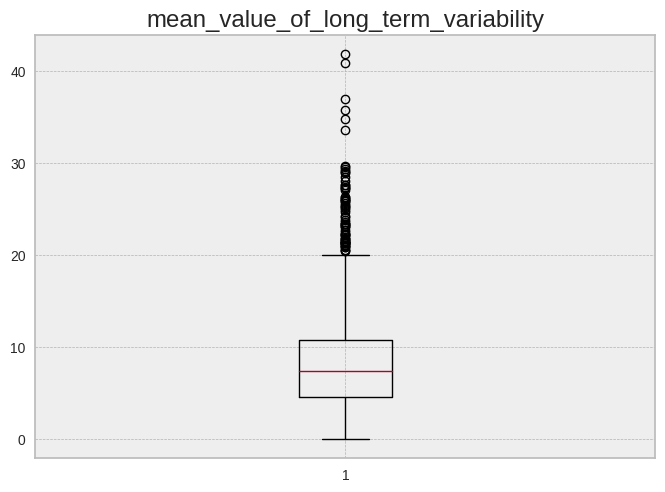

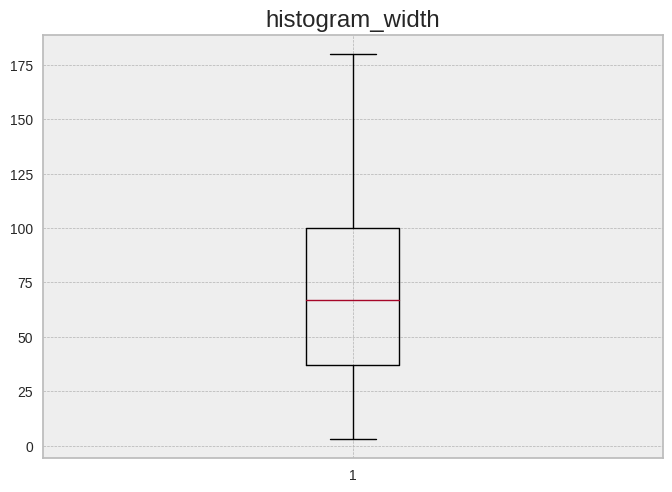

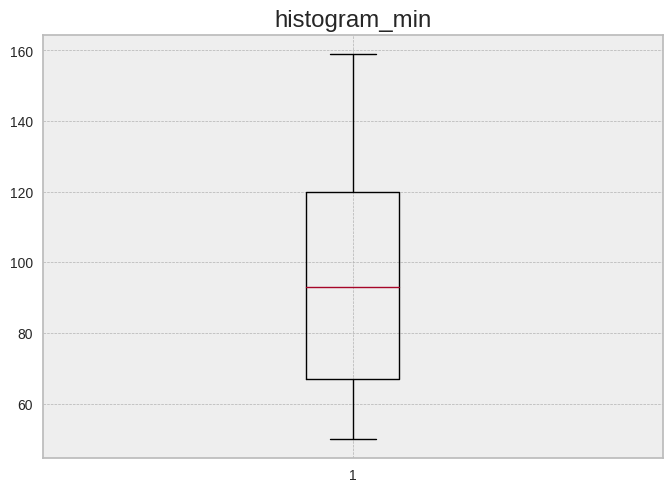

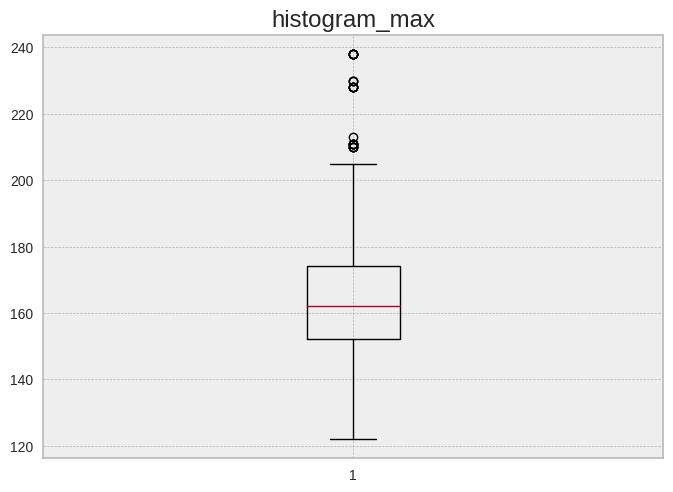

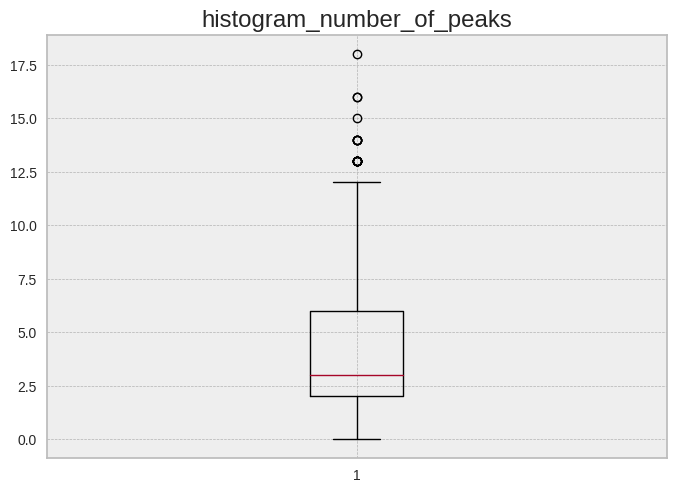

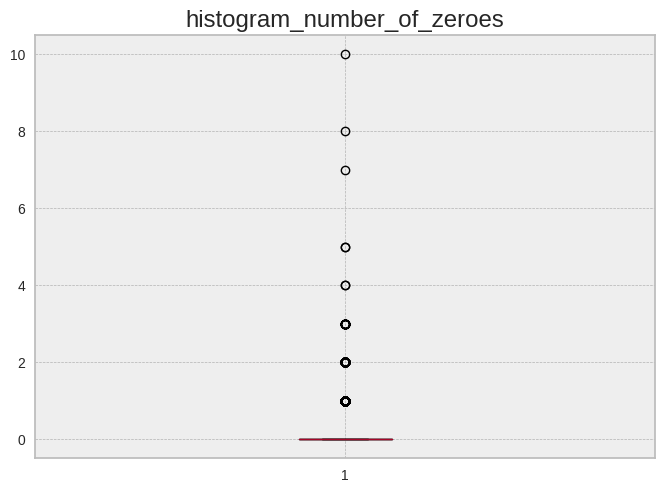

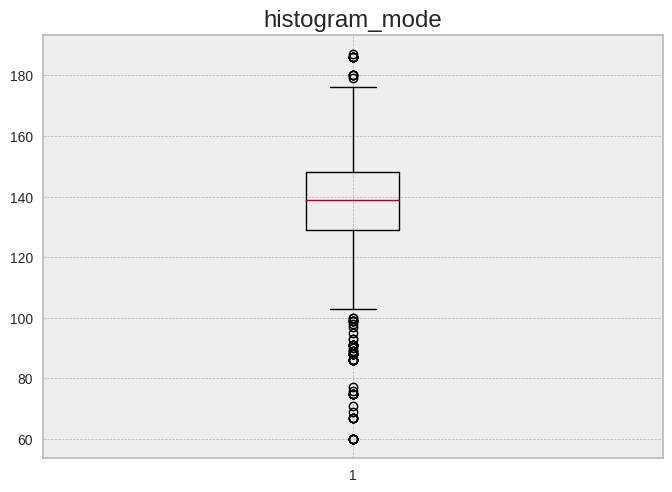

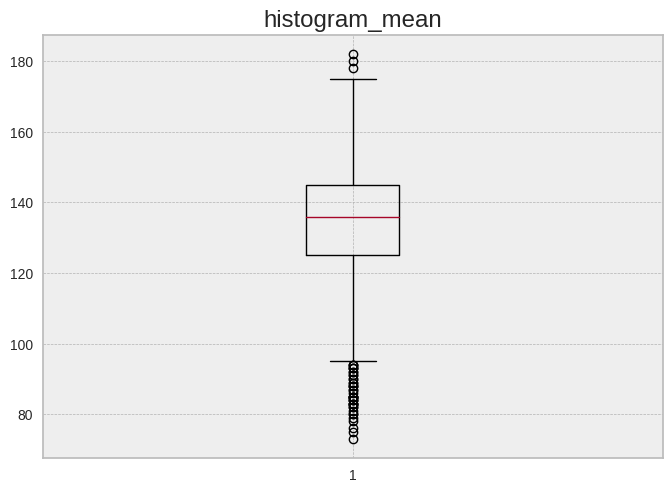

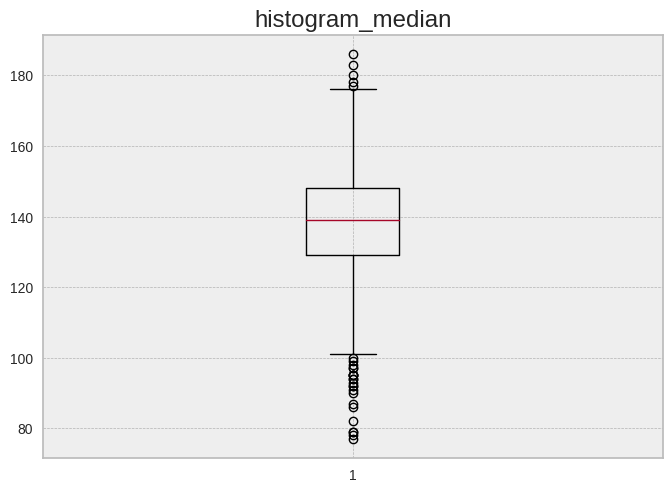

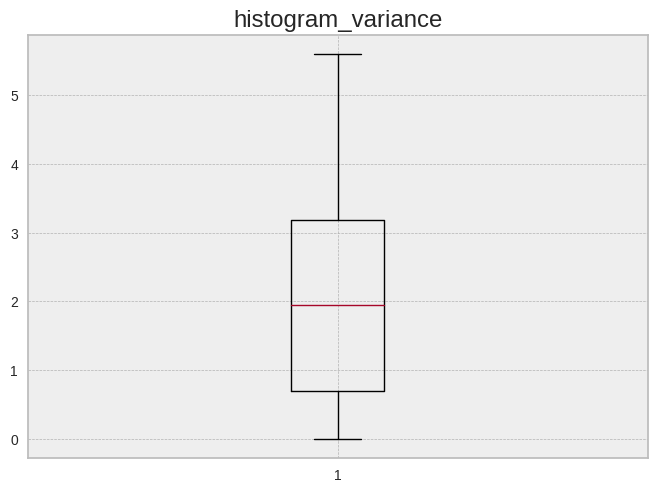

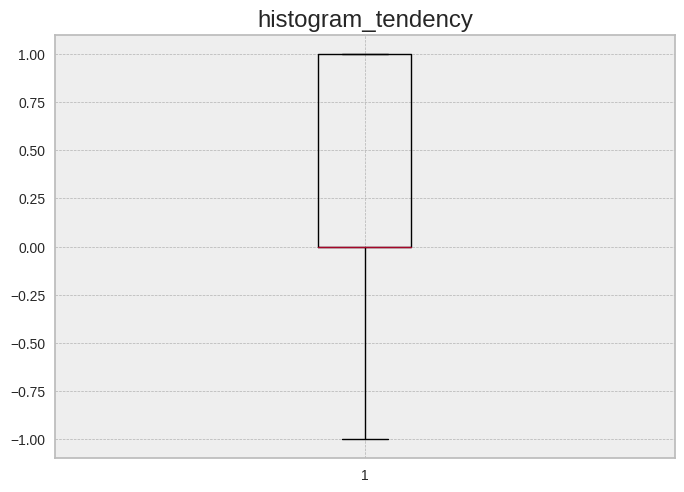

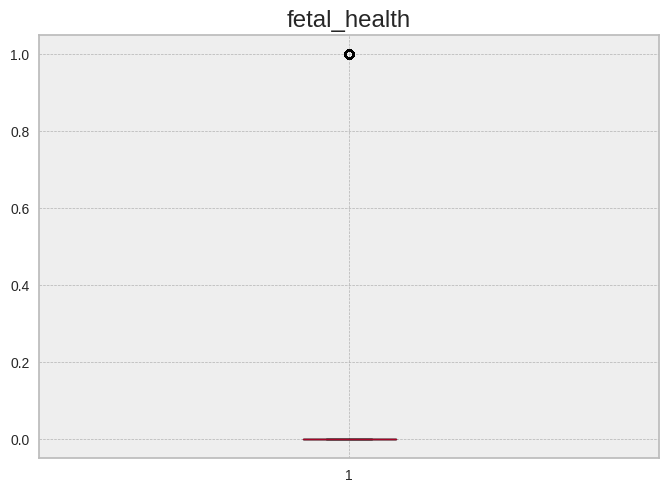

In [45]:
for col in data.columns:
  fig, ax = plt.subplots()
  ax.boxplot(data[col])
  ax.set_title(col)
  plt.show()

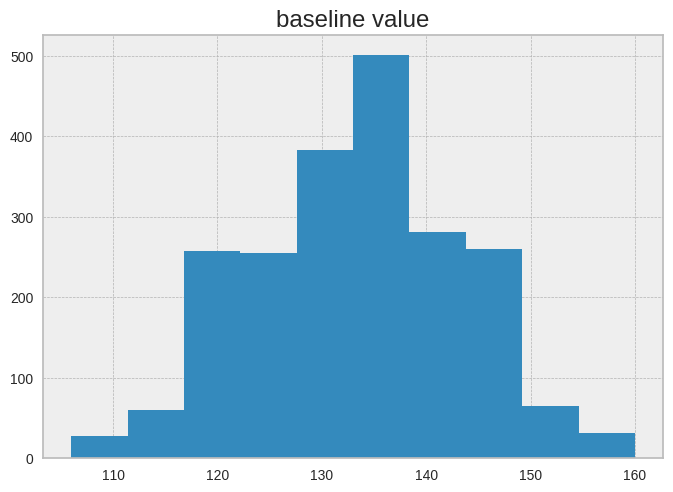

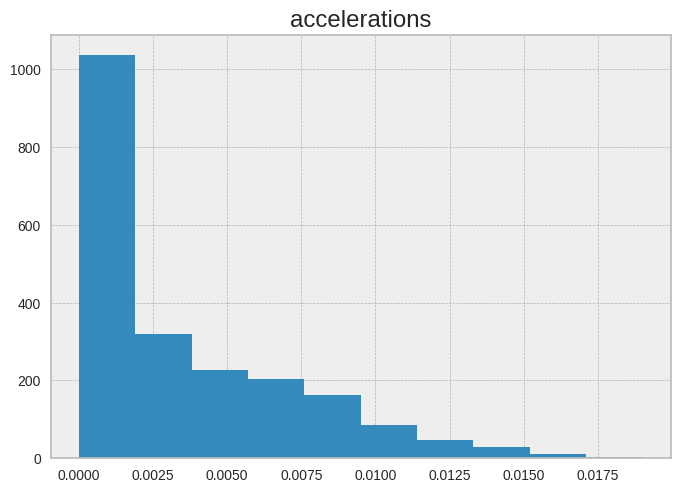

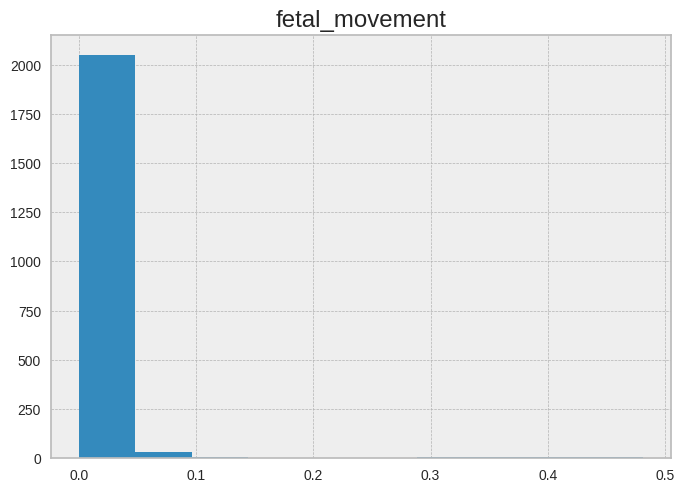

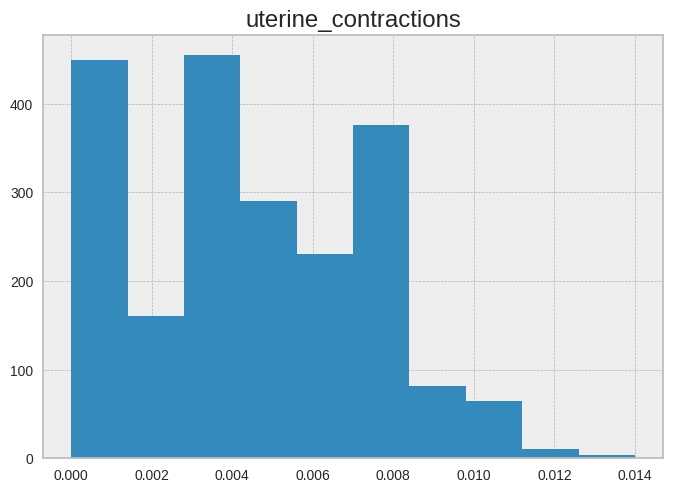

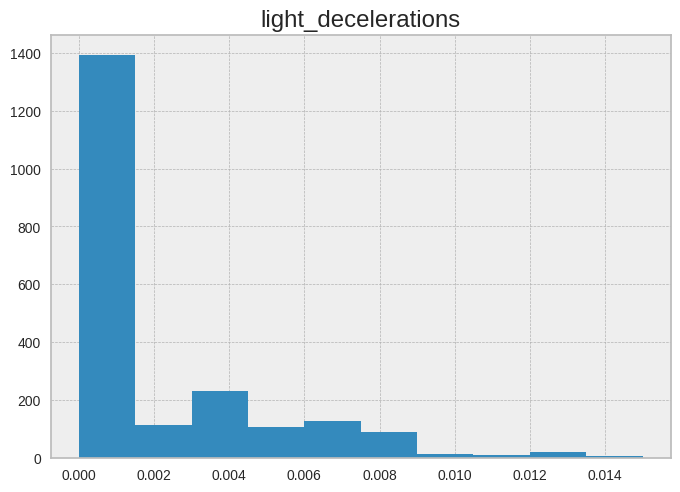

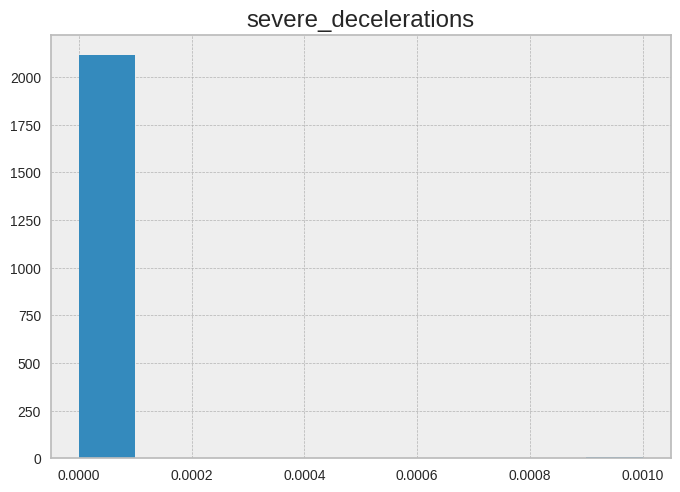

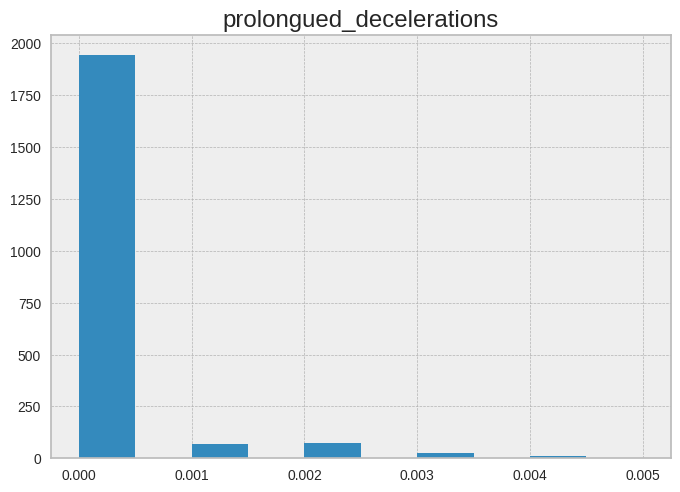

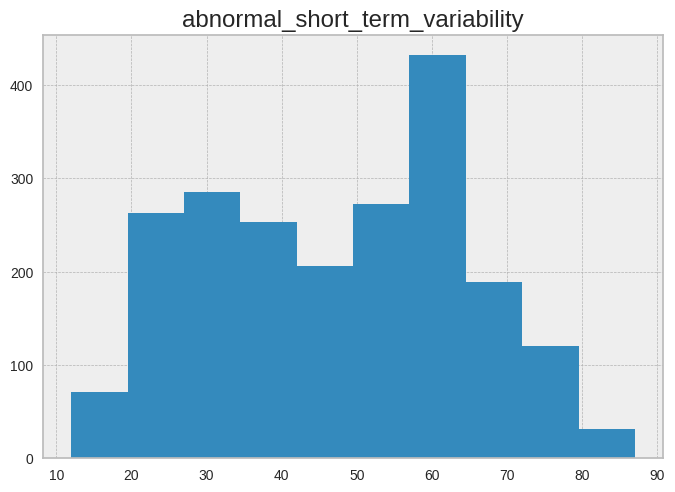

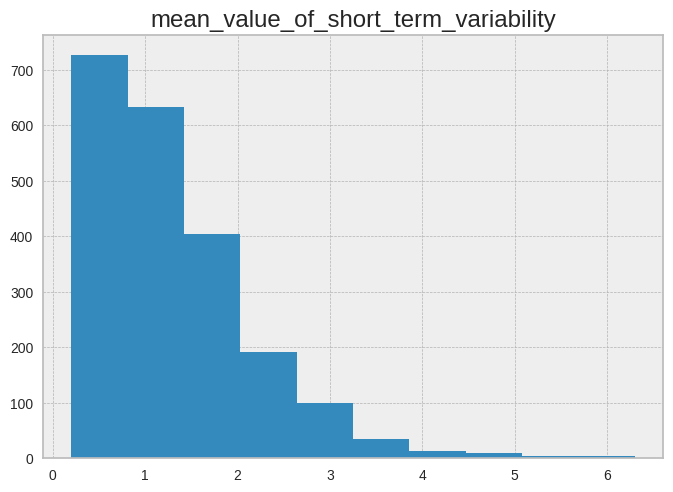

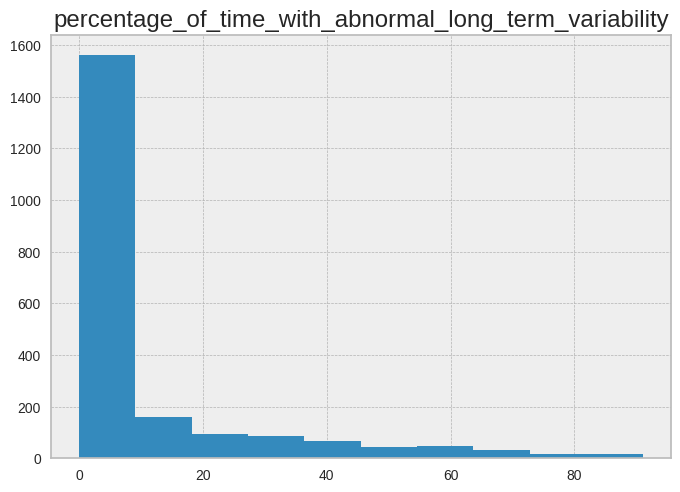

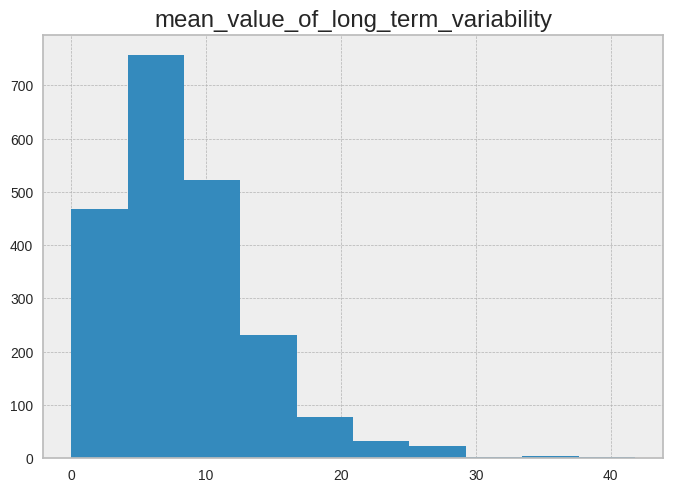

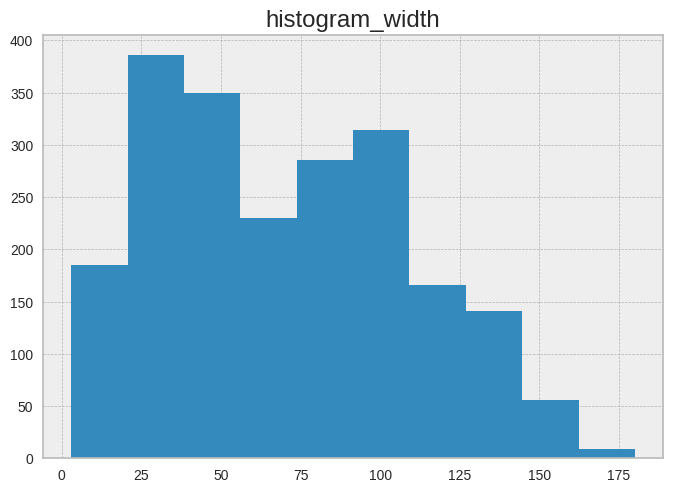

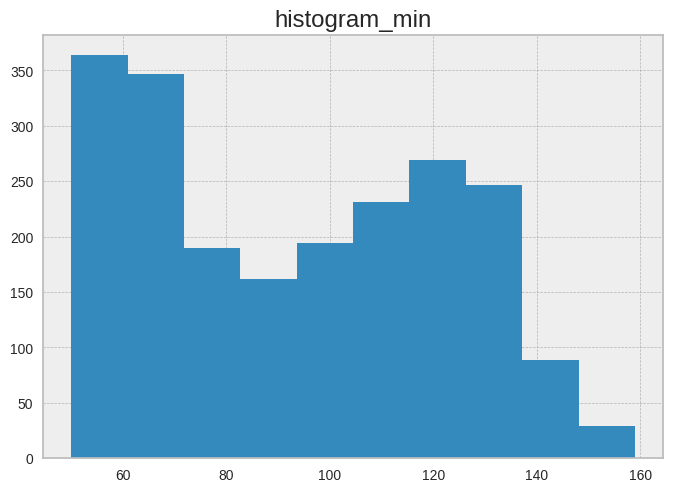

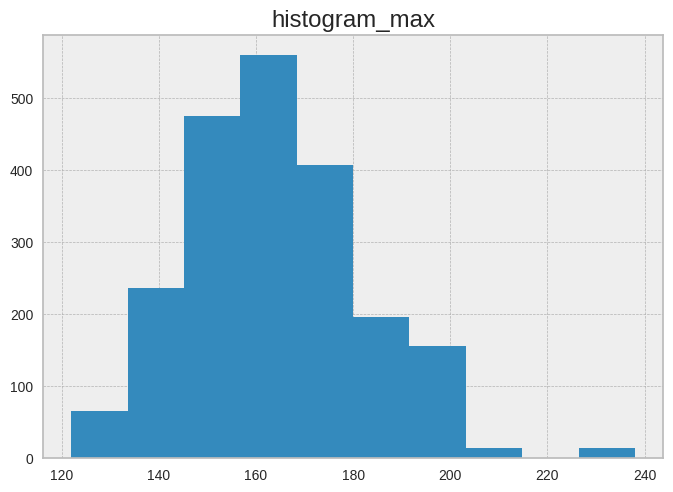

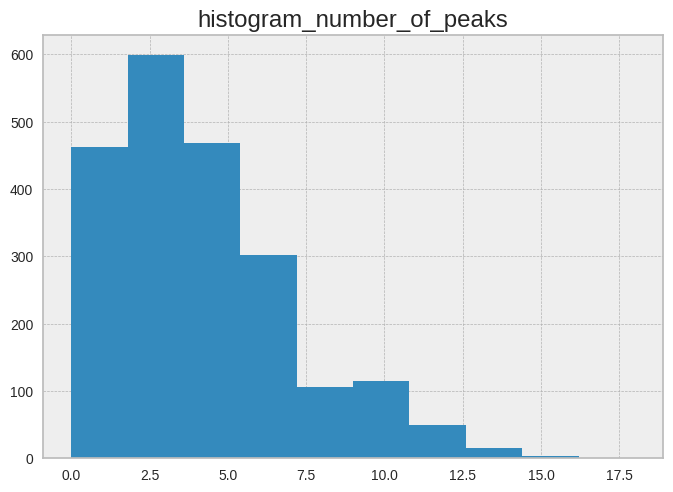

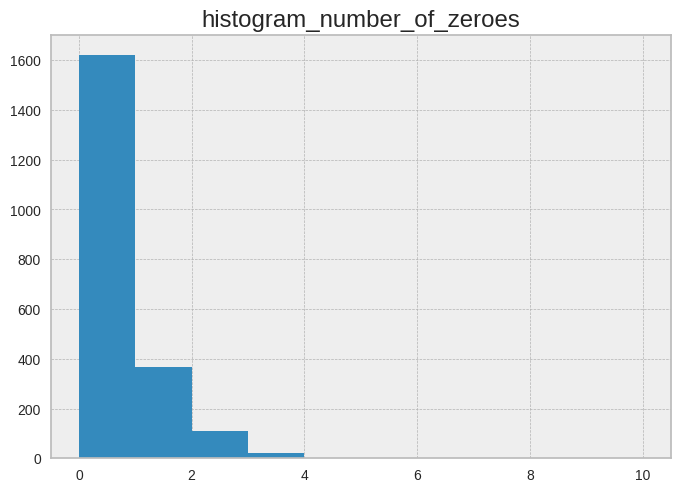

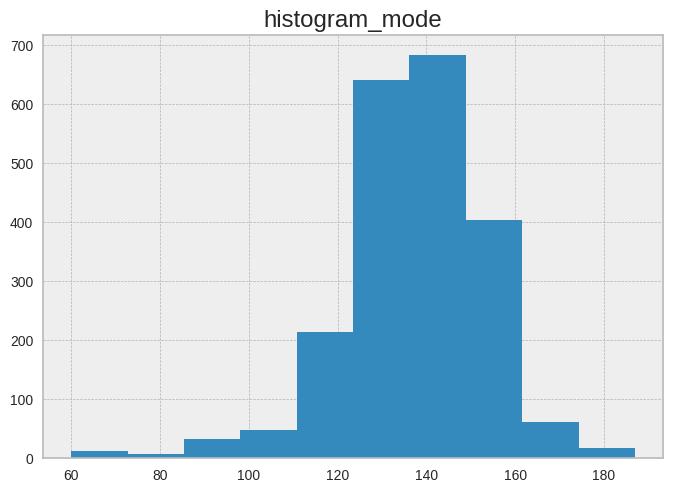

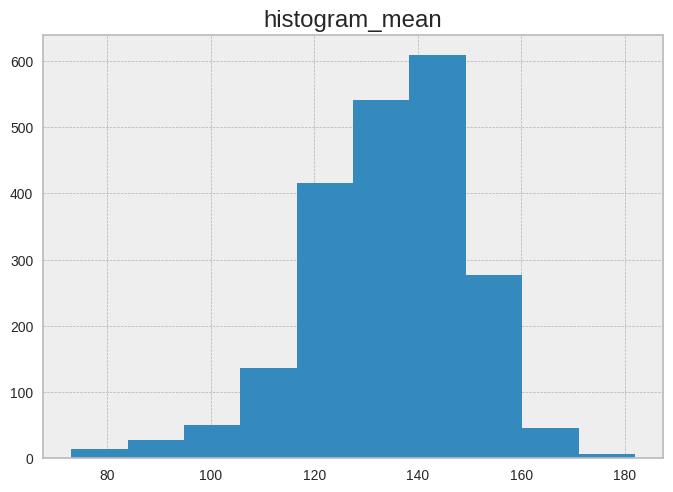

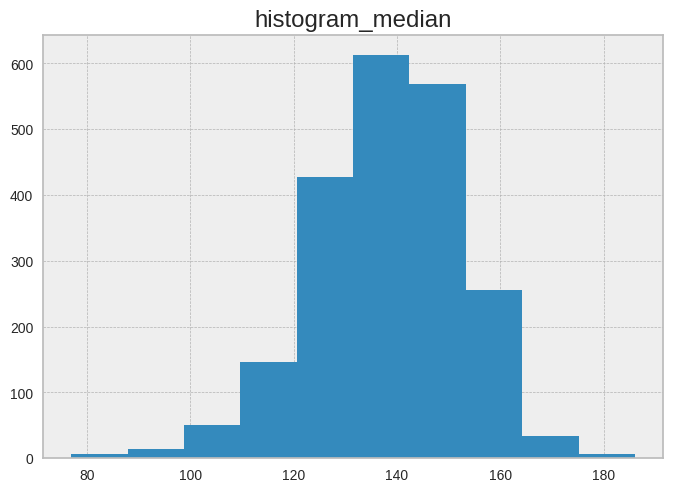

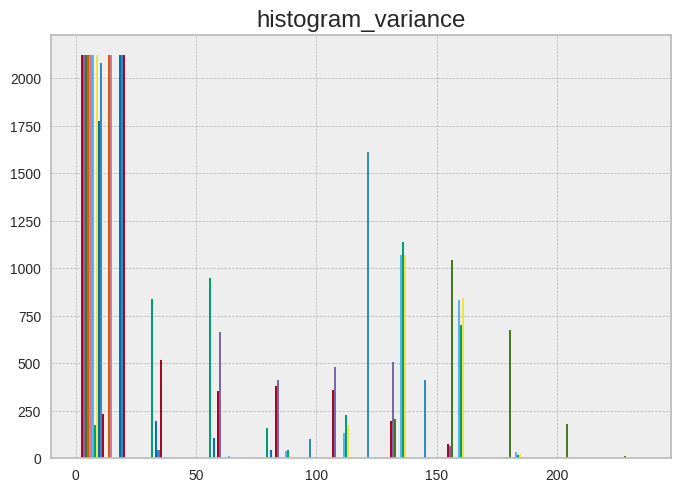

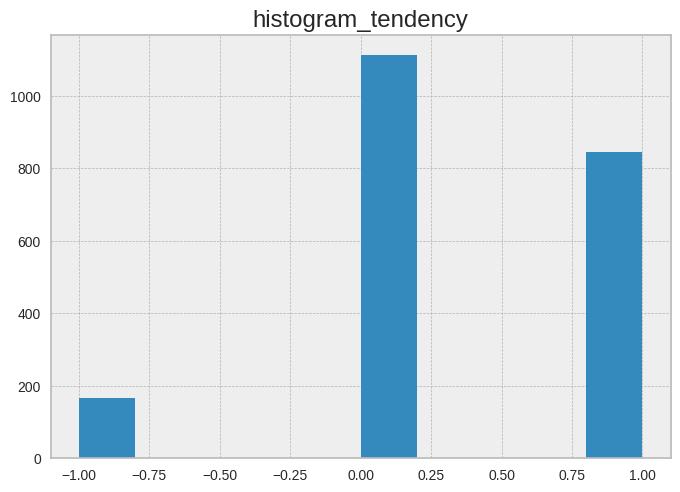

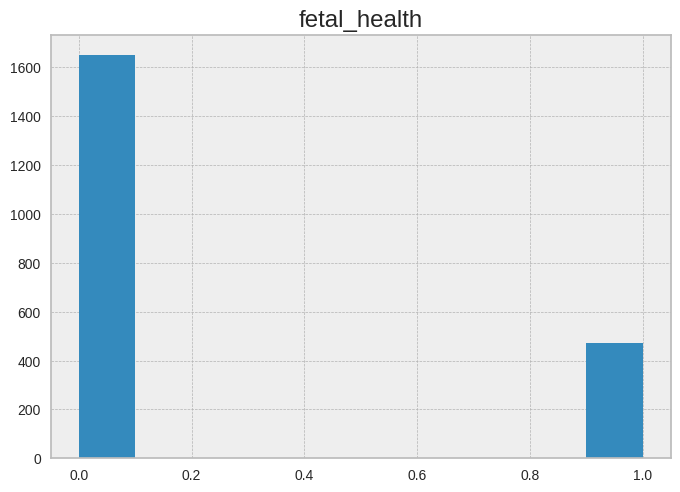

In [46]:
for col in data.columns:
  fig, ax = plt.subplots()
  if col == 'histogram_variance':
    ax.hist(data[np.isfinite(data[col])].values)
  else:
    ax.hist(data[col])
  ax.set_title(col)
  plt.show()

### Análisis multivariado

Generamos la matriz de correlación

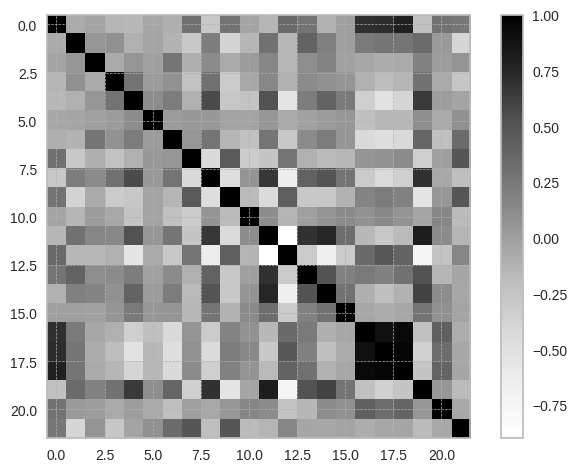

In [47]:
plt.imshow(data.corr())
plt.colorbar()
plt.show()

In [48]:
data.corr()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
baseline value,1.000000,-0.080528,-0.033409,-0.146198,-0.158856,-0.053574,-0.104822,0.305066,-0.281812,0.285436,...,0.361497,0.276962,-0.113527,-0.004904,0.709380,0.723547,0.789875,-0.226659,0.293566,0.251662
accelerations,-0.080528,1.000000,0.049387,0.086572,-0.107020,-0.043037,-0.127760,-0.279699,0.214355,-0.374185,...,-0.155824,0.395929,0.192412,-0.007267,0.242634,0.269328,0.271772,0.345578,0.027178,-0.395031
fetal_movement,-0.033409,0.049387,1.000000,-0.068631,0.045229,-0.010938,0.266483,-0.102629,0.117704,-0.073729,...,-0.152833,0.098284,0.162957,-0.017237,-0.060299,-0.088299,-0.070766,0.178192,-0.000926,0.061530
uterine_contractions,-0.146198,0.086572,-0.068631,1.000000,0.288009,0.006891,0.077677,-0.231369,0.296712,-0.307020,...,-0.115200,0.123085,0.083601,0.056329,-0.107063,-0.189932,-0.142610,0.295009,-0.074673,-0.263893
light_decelerations,-0.158856,-0.107020,0.045229,0.288009,1.000000,0.108184,0.227203,-0.116356,0.560984,-0.271543,...,-0.553350,0.214885,0.395002,0.237807,-0.346673,-0.526498,-0.386730,0.648221,0.001609,-0.031988
severe_decelerations,-0.053574,-0.043037,-0.010938,0.006891,0.108184,1.000000,0.012367,0.033893,0.035293,-0.030837,...,-0.072185,-0.021034,0.007070,0.043446,-0.215284,-0.158875,-0.160668,0.098637,-0.070530,0.087933
prolongued_decelerations,-0.104822,-0.127760,0.266483,0.077677,0.227203,0.012367,1.000000,0.045813,0.274769,-0.137651,...,-0.277680,0.121162,0.223383,0.056395,-0.436724,-0.489379,-0.445480,0.376498,-0.215582,0.340398
abnormal_short_term_variability,0.305066,-0.279699,-0.102629,-0.231369,-0.116356,0.033893,0.045813,1.000000,-0.431969,0.459215,...,0.274671,-0.109509,-0.166223,-0.149558,0.058146,0.073608,0.119118,-0.339848,-0.005751,0.493252
mean_value_of_short_term_variability,-0.281812,0.214355,0.117704,0.296712,0.560984,0.035293,0.274769,-0.431969,1.000000,-0.476447,...,-0.626153,0.405294,0.505202,0.275295,-0.310056,-0.447849,-0.336021,0.688746,-0.063806,-0.208220
percentage_of_time_with_abnormal_long_term_variability,0.285436,-0.374185,-0.073729,-0.307020,-0.271543,-0.030837,-0.137651,0.459215,-0.476447,1.000000,...,0.422637,-0.282507,-0.279492,-0.121966,0.165237,0.222245,0.186382,-0.537346,0.042397,0.489125


Eliminamos las variables que tienen un coeficiente de correlación mayor al 90%, para evitar tener multicolinealidad en nuestro modelo y obtener mejores predicciones.

In [49]:
drops = []
mcorr = data.corr()
for col in mcorr.columns:
  for index in mcorr.columns:
    d = mcorr.filter(like=index, axis=0)
    if abs(d[col].values) > 0.9 and col != index:
      drops.append(index)
print(drops)

['histogram_median', 'histogram_median', 'histogram_mode', 'histogram_mean']


In [50]:
data = data.drop(columns=drops)

In [51]:
data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_variance,histogram_tendency,fetal_health
0,120,0.000,0.000,0.000,0.000,0.0,0.0,73,0.5,43.0,2.4,64,62,126,2,0,4.290459,1.0,1
1,132,0.006,0.000,0.006,0.003,0.0,0.0,17,2.1,0.0,10.4,130,68,198,6,1,2.484907,0.0,0
2,133,0.003,0.000,0.008,0.003,0.0,0.0,16,2.1,0.0,13.4,130,68,198,5,1,2.564949,0.0,0
3,134,0.003,0.000,0.008,0.003,0.0,0.0,16,2.4,0.0,23.0,117,53,170,11,0,2.564949,1.0,0
4,132,0.007,0.000,0.008,0.000,0.0,0.0,16,2.4,0.0,19.9,117,53,170,9,0,2.397895,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140,0.000,0.000,0.007,0.000,0.0,0.0,79,0.2,25.0,7.2,40,137,177,4,0,0.693147,0.0,1
2122,140,0.001,0.000,0.007,0.000,0.0,0.0,78,0.4,22.0,7.1,66,103,169,6,0,1.098612,1.0,1
2123,140,0.001,0.000,0.007,0.000,0.0,0.0,79,0.4,20.0,6.1,67,103,170,5,0,1.386294,1.0,1
2124,140,0.001,0.000,0.006,0.000,0.0,0.0,78,0.4,27.0,7.0,66,103,169,6,0,1.386294,1.0,1


Observamos de nuevo la matriz de correlación sin las variables anteriores.

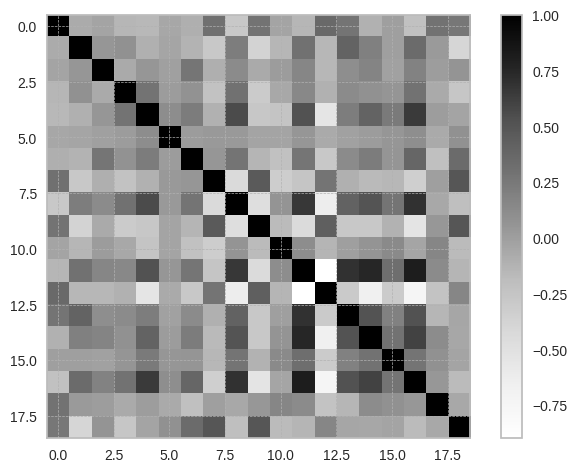

In [52]:
plt.imshow(data.corr())
plt.colorbar()
plt.show()

# Selección de variables

Eliminamos esas variables que tienen poca varianza, ya que no van a ser útiles para nuestro modelo.

In [53]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
data_select = selector.fit_transform(data)

In [54]:
selector.get_support(indices = True)

array([ 0,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18])

In [55]:
features = selector.get_support(indices = True)
cols = []
for i, col in enumerate(data.columns):
  if i in features:
    cols.append(col)
print(cols)

['baseline value', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_min', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_variance', 'histogram_tendency', 'fetal_health']


In [56]:
data_select = pd.DataFrame(data_select)
data_select.columns = cols

In [57]:
data = data_select
data

,baseline value,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_variance,histogram_tendency,fetal_health
0,120.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,4.290459,1.0,1.0
1,132.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,2.484907,0.0,0.0
2,133.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,2.564949,0.0,0.0
3,134.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,2.564949,1.0,0.0
4,132.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,2.397895,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2117,140.0,79.0,0.2,25.0,7.2,40.0,137.0,177.0,4.0,0.0,0.693147,0.0,1.0
2118,140.0,78.0,0.4,22.0,7.1,66.0,103.0,169.0,6.0,0.0,1.098612,1.0,1.0
2119,140.0,79.0,0.4,20.0,6.1,67.0,103.0,170.0,5.0,0.0,1.386294,1.0,1.0
2120,140.0,78.0,0.4,27.0,7.0,66.0,103.0,169.0,6.0,0.0,1.386294,1.0,1.0


# Separación de datos

In [58]:
X = data.drop(columns='fetal_health')
y = data[['fetal_health']]

In [59]:
from sklearn.model_selection import train_test_split
train, test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [60]:
print(len(train), len(test), len(y_train), len(y_test))

1697 425 1697 425


# Balanceo de clases

In [61]:
from imblearn.over_sampling import RandomOverSampler
oversampler = RandomOverSampler(random_state=0)
train_over, y_train_over = oversampler.fit_resample(train, y_train)
print(len(train_over[y_train_over['fetal_health']==0]))
print(len(train_over[y_train_over['fetal_health']==1]))

1315
1315


In [62]:
oversampler = RandomOverSampler(random_state=0)
test_over, y_test_over = oversampler.fit_resample(test, y_test)
print(len(test_over[y_test_over['fetal_health']==0]))
print(len(test_over[y_test_over['fetal_health']==1]))

336
336


# Transformaciones

### Escalado

In [39]:
from sklearn.preprocessing import MinMaxScaler
escalado = MinMaxScaler()
train_scaled = escalado.fit_transform(pd.concat([train_over, y_train_over], axis=1))
train_scaled = pd.DataFrame(train_scaled, columns=data.columns)
test_scaled = escalado.fit_transform(pd.concat([test_over, y_test_over], axis=1))
test_scaled = pd.DataFrame(test_scaled, columns=data.columns)
X_train_scaled = train_scaled.drop(columns='fetal_health')
y_train_scaled = train_scaled['fetal_health']
X_test_scaled = test_scaled.drop(columns='fetal_health')
y_test_scaled = test_scaled['fetal_health']

In [40]:
train_scaled.describe()

,baseline value,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_variance,histogram_tendency,fetal_health
count,2630.000000,2630.000000,2630.000000,2630.000000,2630.000000,2630.000000,2630.000000,2630.000000,2630.000000,2630.000000,2630.000000,2630.000000,2630.000000
mean,0.539354,0.543523,0.157252,0.177658,0.181584,0.356046,0.435134,0.357326,0.219096,0.030342,0.314782,0.652091,0.500000
std,0.188857,0.232484,0.143525,0.253431,0.120716,0.233723,0.292280,0.156672,0.172157,0.075733,0.280905,0.319080,0.500095
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.407407,0.346667,0.049180,0.000000,0.107656,0.146893,0.155963,0.250000,0.055556,0.000000,0.000000,0.500000,0.000000
50%,0.537037,0.613333,0.114754,0.032967,0.167464,0.322034,0.467890,0.336207,0.166667,0.000000,0.247787,0.500000,0.500000
75%,0.685185,0.706667,0.229508,0.296703,0.239234,0.542373,0.706422,0.448276,0.333333,0.000000,0.552494,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Normalización

In [41]:
from sklearn.preprocessing import normalize
train_norm = pd.DataFrame(normalize(pd.concat([train_over, y_train_over], axis=1)), columns=data.columns)
test_norm = pd.DataFrame(normalize(pd.concat([test_over, y_test_over], axis=1)), columns=data.columns)
y_train_norm = train_norm['fetal_health']
train_norm = train_norm.drop(columns='fetal_health')
y_test_norm = test_norm['fetal_health']
test_norm = test_norm.drop(columns='fetal_health')

### Estandarización

In [63]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler.fit(pd.concat([train_over, y_train_over], axis=1))
train_std = std_scaler.transform(pd.concat([train_over, y_train_over], axis=1))
train_std = pd.DataFrame(train_std, columns=data.columns)
test_std = std_scaler.transform(pd.concat([test_over, y_test_over], axis=1))
test_std = pd.DataFrame(test_std, columns=data.columns)

In [64]:
train_std.describe()

,baseline value,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_variance,histogram_tendency,fetal_health
count,2.630000e+03,2.630000e+03,2.630000e+03,2.630000e+03,2.630000e+03,2.630000e+03,2.630000e+03,2.630000e+03,2.630000e+03,2.630000e+03,2.630000e+03,2.630000e+03,2630.00000
mean,-9.077656e-16,-1.512943e-16,2.161347e-17,6.484040e-17,-1.945212e-16,-1.296808e-16,2.053279e-16,7.294545e-17,1.080673e-17,-3.512188e-17,-1.729077e-16,4.457778e-17,0.00000
std,1.000190e+00,1.000190e+00,1.000190e+00,1.000190e+00,1.000190e+00,1.000190e+00,1.000190e+00,1.000190e+00,1.000190e+00,1.000190e+00,1.000190e+00,1.000190e+00,1.00019
min,-2.856432e+00,-2.338339e+00,-1.095850e+00,-7.011455e-01,-1.504516e+00,-1.523654e+00,-1.489044e+00,-2.281163e+00,-1.272891e+00,-4.007220e-01,-1.120810e+00,-2.044051e+00,-1.00000
25%,-6.987908e-01,-8.469145e-01,-7.531256e-01,-7.011455e-01,-6.125373e-01,-8.950458e-01,-9.553323e-01,-6.851671e-01,-9.501274e-01,-4.007220e-01,-1.120810e+00,-4.767465e-01,-1.00000
50%,-1.226865e-02,3.003351e-01,-2.961593e-01,-5.710380e-01,-1.169936e-01,-1.455508e-01,1.120901e-01,-1.348237e-01,-3.046004e-01,-4.007220e-01,-2.385420e-01,-4.767465e-01,0.00000
75%,7.723281e-01,7.018724e-01,5.035316e-01,4.698214e-01,4.776590e-01,7.973623e-01,9.283543e-01,5.806227e-01,6.636901e-01,-4.007220e-01,8.463966e-01,1.090558e+00,1.00000
max,2.439596e+00,1.963847e+00,5.872885e+00,3.245447e+00,6.780976e+00,2.755720e+00,1.932987e+00,4.102820e+00,4.536852e+00,1.280603e+01,2.439786e+00,1.090558e+00,1.00000


# PCA

In [44]:
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
X_train_std = train_std.drop(columns='fetal_health')
y_train_std = train_std['fetal_health']
X_test_std = test_std.drop(columns='fetal_health')
y_test_std = test_std['fetal_health']
pca = PCA(n_components=2)
X_train_pca = pca.fit(X_train_std).transform(X_train_std)
X_test_pca = pca.fit(X_test_std).transform(X_test_std)

# Funciones

Creamos primero un *dataframe* donde iremos añadiendo las métricas de nuestros modelos para poder compararlos al final

In [45]:
global metricas
metricas = pd.DataFrame(columns=['algoritmo', 'accuracy', 'precision', 'recall', 'f1_score', 'auc'])

In [46]:
metricas

,algoritmo,accuracy,precision,recall,f1_score,auc


A continuación creamos las diferentes funciones que vamos a usar recurrentemente en los algoritmos que creemos.

Creamos una función que nos calcule las siguientes métricas:


*   Matriz de confusión
*   Curva ROC
*   Accuracy
*   Precision
*   Recall
*   F1 score
*   Area under the curve (AUC)



In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, auc, RocCurveDisplay, f1_score

def get_metricas(clf, data_test, clf_test, label_range):
  global metricas
  fila = {}
  y_pred = clf.predict(data_test)
  y_prob = clf.predict_proba(data_test)
  CM = confusion_matrix(y_pred, clf_test, labels = label_range)
  ConfusionMatrixDisplay(CM, display_labels=label_range).plot()
  fpr, tpr, thresholds = roc_curve(clf_test, y_prob[:,1])
  display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc(fpr, tpr))
  display.plot()
  fila = {
      'algoritmo': clf.__class__.__name__,
      'accuracy': accuracy_score(clf_test, y_pred),
      'precision': precision_score(clf_test, y_pred),
      'recall': recall_score(clf_test, y_pred),
      'f1_score': f1_score(clf_test, y_pred),
      'auc': auc(fpr, tpr)
  }
  fila = pd.DataFrame([fila])
  if metricas.empty:
    metricas = fila
  else:
    metricas = pd.concat([metricas, fila], ignore_index=True)

Creamos otra función que nos calcula un cross-validation (CV) del algoritmo que le pasamos para determinar, a través de *randomized search*, cuáles son los mejores hiperparámetros del modelo para nuestros datos.

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

def get_best(clf, params, cv, x, labels):
  rcv = RandomizedSearchCV(clf, params, cv=cv)
  rcv.fit(x, labels)
  return rcv.best_estimator_

# Regresión Logística

In [49]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
params = {
    "C": uniform(0, 100), # factor de regularización
    "fit_intercept": [True, False],
    "solver": ['lbfgs', 'liblinear', 'newton-cg', 'sag']
}
log_reg = get_best(log_reg, params, 5, X_train_std, y_train_std)
print(log_reg.score(X_train_std, y_train_std), log_reg.score(X_test_std, y_test_std))
log_reg.predict_proba(X_test_std)

0.8224334600760457 0.8303571428571429


array([[0.67969068, 0.32030932],
       [0.64006813, 0.35993187],
       [0.9270317 , 0.0729683 ],
       ...,
       [0.29660803, 0.70339197],
       [0.25833533, 0.74166467],
       [0.2788195 , 0.7211805 ]])

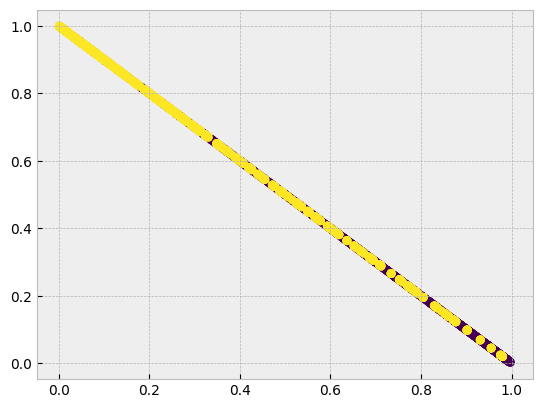

In [50]:
plt.scatter(log_reg.predict_proba(X_train_std)[:,0], log_reg.predict_proba(X_train_std)[:,1], c=y_train_std)

Observamos las métricas de este algoritmo

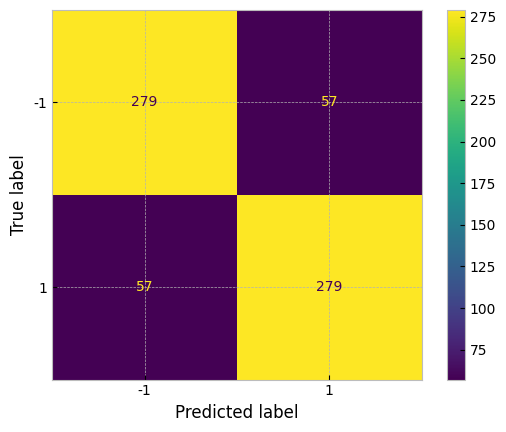

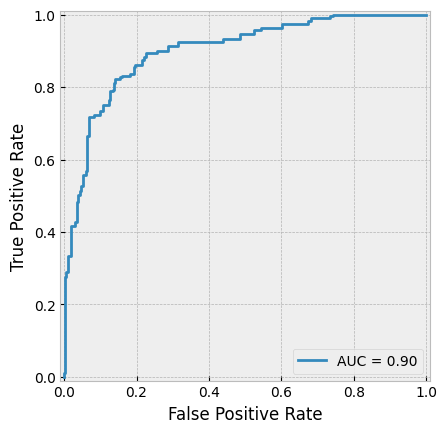

In [51]:
get_metricas(log_reg, X_test_std, y_test_std, [-1,1])

Aplicamos el mismo algoritmo con los datos en formato PCA. \\
Esto nos permite crear un gráfico en 2D para visualizar los datos.

In [52]:
clf_pca = LogisticRegression().fit(X_train_pca, y_train_std)
print(clf_pca.score(X_train_pca, y_train_std), clf_pca.score(X_test_pca, y_test_std))

0.7349809885931559 0.5327380952380952


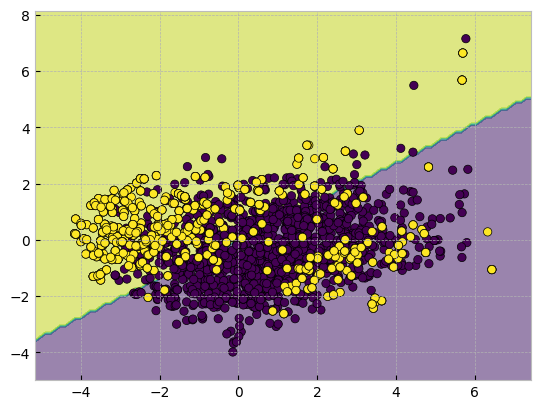

In [53]:
disp = DecisionBoundaryDisplay.from_estimator(
    clf_pca, X_train_pca, response_method="predict",
    alpha=0.5
)
disp.ax_.scatter(X_train_pca[:, 0], X_train_pca[:,1], c=y_train_std, edgecolor="k")

# Naive Bayes

In [54]:
from sklearn.naive_bayes import MultinomialNB
NB = MultinomialNB()
params = {
    "alpha": uniform(0, 1), # estabiliza las probabilidades del algoritmo
    "fit_prior": [True, False]
}
NB = get_best(NB, params, 5, X_train_scaled, y_train_scaled)

print(NB.score(X_train_scaled, y_train_scaled))
print(NB.score(X_test_scaled, y_test_scaled))

0.7323193916349809
0.6800595238095238


Observamos las métricas del algoritmo

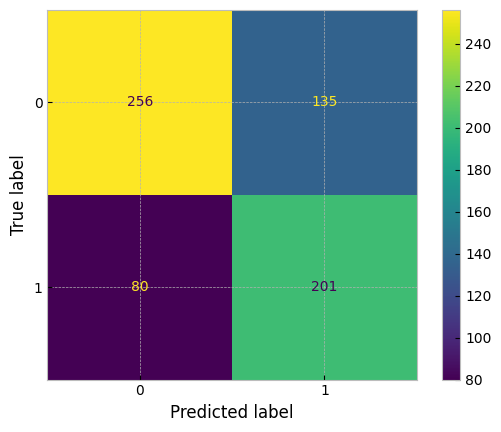

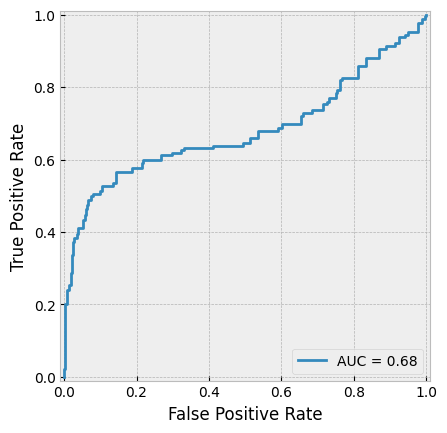

In [55]:
get_metricas(NB, X_test_scaled, y_test_scaled, [0,1])

Aplicamos el algoritmo con datos de PCA, pero teniendo en cuenta que se tiene que escalar el PCA antes de usar Naive Bayes. \\
Recordemos que Naive Bayes solo acepta valores positivos como input.

0.7334600760456274 0.5505952380952381


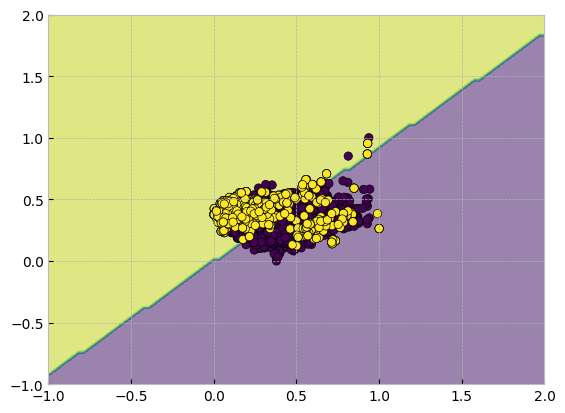

In [56]:
scaler = MinMaxScaler()
scaler.fit(X_train_pca)
X_train_pca_scaled = scaler.transform(X_train_pca)
X_test_pca_scaled = scaler.transform(X_test_pca)
clf_pca = MultinomialNB().fit(X_train_pca_scaled, y_train_scaled)
print(clf_pca.score(X_train_pca_scaled, y_train_scaled), clf_pca.score(X_test_pca_scaled, y_test_scaled))
clf_pca.predict_proba(X_test_pca_scaled)
disp = DecisionBoundaryDisplay.from_estimator(
    clf_pca, X_train_pca_scaled, response_method="predict",
    alpha=0.5
)
disp.ax_.scatter(X_train_pca_scaled[:, 0], X_train_pca_scaled[:,1], c=y_train_scaled, edgecolor="k")

# K-Nearest Neighbours

In [57]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier()
params = {
    "n_neighbors": [1, 3, 5, 7, 9],
    "weights": ['uniform', 'distance', None],
    'leaf_size': [10, 20, 30, 40],
    "metric": ['minkowski', 'euclidean']
}
neigh = get_best(neigh, params, 5, X_train_scaled, y_train_scaled)

print(neigh.score(X_train_scaled, y_train_scaled))
print(neigh.score(X_test_scaled, y_test_scaled))

1.0
0.8467261904761905


### Métricas

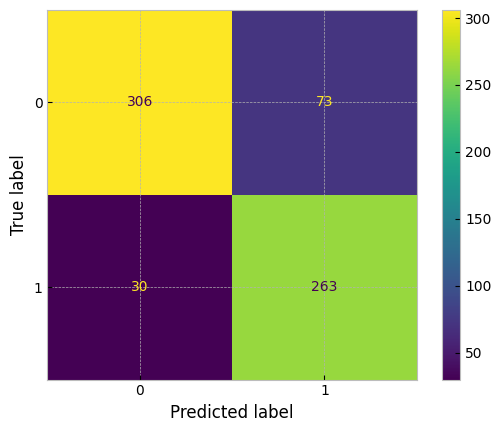

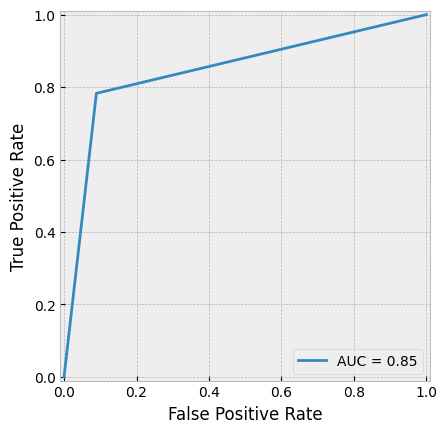

In [58]:
get_metricas(neigh, X_test_scaled, y_test_scaled, [0,1])

### Visualización

1.0
0.5833333333333334


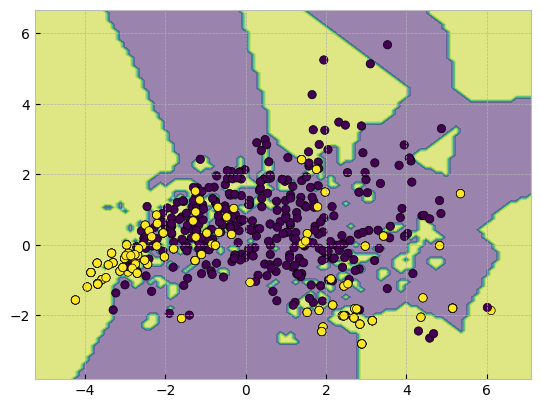

In [59]:
neigh_pca = KNeighborsClassifier(n_neighbors=1, weights='distance', metric='euclidean')
neigh_pca.fit(X_train_pca, y_train_scaled)
print(neigh_pca.score(X_train_pca, y_train_scaled))
print(neigh_pca.score(X_test_pca, y_test_scaled))
disp = DecisionBoundaryDisplay.from_estimator(
    neigh_pca, X_test_pca, response_method="predict",
    alpha=0.5
)
disp.ax_.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_scaled, edgecolor="k")

# Decision Tree

In [60]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
params = {
    "criterion": ['gini', 'entropy', 'log_loss'], # criterio a minimizar
    "splitter": ['best', 'random'],
    'max_depth': [1, 3, 5, 10, 15],
    "min_samples_split": [2, 5, 10, 15, 20]
}
dtree = get_best(dtree, params, 5, train, y_train)
print(dtree.score(train, y_train))
print(dtree.score(test, y_test))

0.9752504419563937
0.9129411764705883


### Métricas

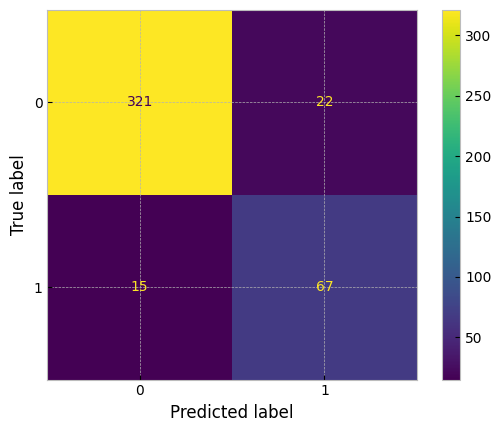

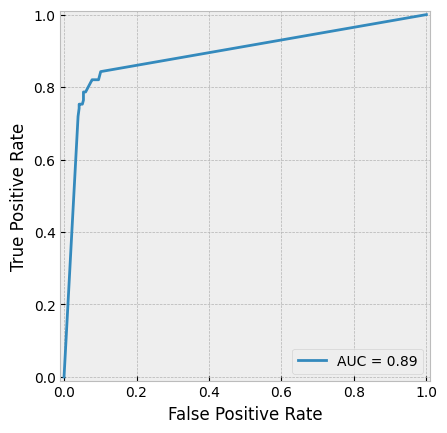

In [61]:
get_metricas(dtree, test, y_test, [0,1])

### Visualización

[Text(0.572985197368421, 0.9583333333333334, 'x[1] <= 59.5\nlog_loss = 0.769\nsamples = 1697\nvalue = [1315, 382]\nclass = 0'),
 Text(0.3926809210526316, 0.875, 'x[3] <= 9.5\nlog_loss = 0.368\nsamples = 1178\nvalue = [1095, 83]\nclass = 0'),
 Text(0.4828330592105263, 0.9166666666666667, 'True  '),
 Text(0.2754934210526316, 0.7916666666666666, 'x[10] <= 3.961\nlog_loss = 0.254\nsamples = 961\nvalue = [920, 41]\nclass = 0'),
 Text(0.20888157894736842, 0.7083333333333334, 'x[6] <= 138.5\nlog_loss = 0.166\nsamples = 857\nvalue = [836, 21]\nclass = 0'),
 Text(0.16776315789473684, 0.625, 'x[7] <= 189.5\nlog_loss = 0.123\nsamples = 833\nvalue = [819, 14]\nclass = 0'),
 Text(0.125, 0.5416666666666666, 'x[6] <= 69.5\nlog_loss = 0.1\nsamples = 770\nvalue = [760, 10]\nclass = 0'),
 Text(0.07894736842105263, 0.4583333333333333, 'x[8] <= 6.5\nlog_loss = 0.192\nsamples = 203\nvalue = [197, 6]\nclass = 0'),
 Text(0.06578947368421052, 0.375, 'x[11] <= 0.5\nlog_loss = 0.275\nsamples = 127\nvalue = [121

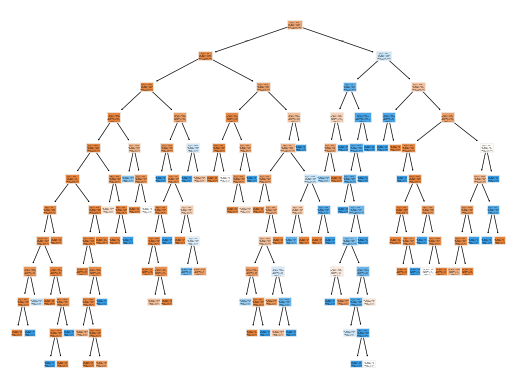

In [62]:
from sklearn.tree import plot_tree
plot_tree(dtree, class_names = ['0','1'], filled=True)

# Stochastic Gradient Descent (SGD)

In [63]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier()
params = {
    "loss": ['modified_huber', 'log_loss'], #solo podemos usar estas porque son las únicas que permiten calcular la probabilidad para las métricas
    "penalty": ['l1', 'l2', 'elasticnet', None], # regularización
    'alpha': uniform(0, 10), # evita overfitting
    "l1_ratio": uniform(0,1)
}
sgd = get_best(sgd, params, 5, X_train_std, y_train_std)

print(sgd.score(X_train_std, y_train_std))
print(sgd.score(X_test_std, y_test_std))

0.7980988593155893
0.7514880952380952


### Métricas

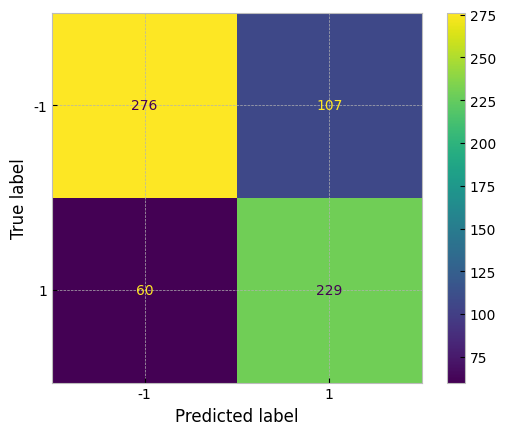

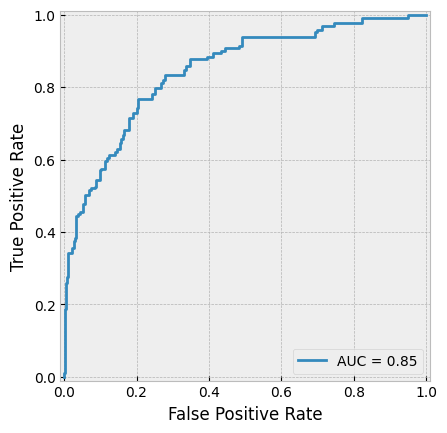

In [64]:
get_metricas(sgd, X_test_std, y_test_std, [-1,1])

### Visualización

0.5718631178707224
0.25


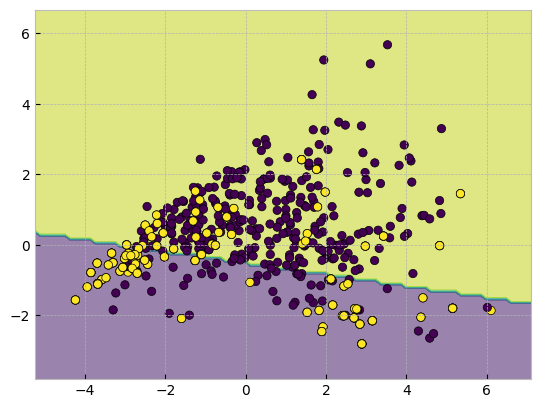

In [65]:
sgd_pca = SGDClassifier()
sgd_pca.fit(X_train_pca, y_train_std)
print(sgd_pca.score(X_train_pca, y_train_std))
print(sgd_pca.score(X_test_pca, y_test_std))
disp = DecisionBoundaryDisplay.from_estimator(
    sgd_pca, X_test_pca, response_method="predict",
    alpha=0.5
)
disp.ax_.scatter(X_test_pca[:, 0], X_test_pca[:,1], c=y_test_std, edgecolor="k")

# Support Vector Machine

Cambiaremos el número máximo de iteraciones de algoritmo y también la función de calcular las probabilidades para poder obtener las métricas posteriormente.

In [66]:
from sklearn.svm import SVC
svc = SVC()
params = {
    "C": uniform(0.000001, 100), # factor de regularización
    "kernel": ['linear', 'poly', 'rbf'],
    'probability': [True], # necesario para poder calcular métricas
    "max_iter": [10, 50, 100, 250, 500, 800]
}
svc = get_best(svc, params, 5, X_train_std, y_train_std)

print(svc.score(X_train_std, y_train_std))
print(svc.score(X_test_std, y_test_std))


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-proce

0.961596958174905
0.8363095238095238


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=800).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


### Métricas

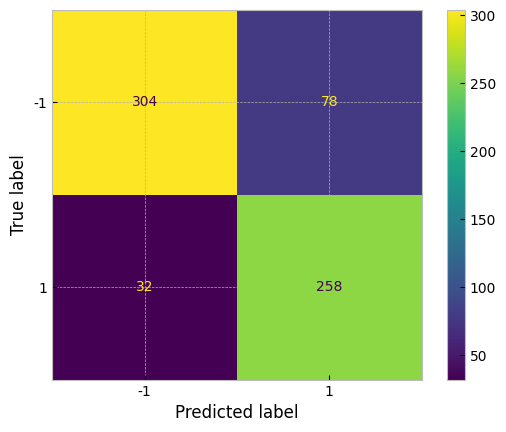

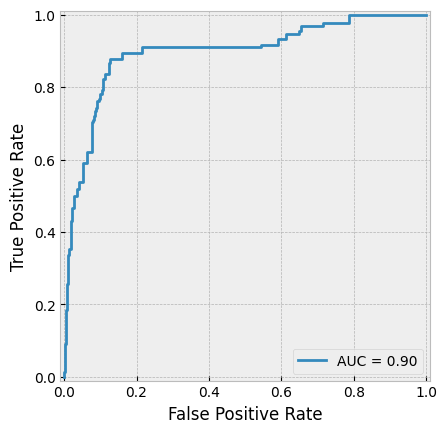

In [67]:
get_metricas(svc, X_test_std, y_test_std, [-1,1])

### Visualización

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.49923954372623575
0.4419642857142857


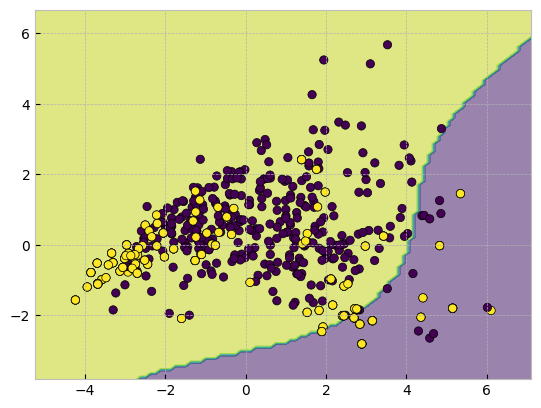

In [68]:
svc_pca = SVC(max_iter=1000, kernel='poly')
svc_pca.fit(X_train_pca, y_train_std)
print(svc_pca.score(X_train_pca, y_train_std))
print(svc_pca.score(X_test_pca, y_test_std))
disp = DecisionBoundaryDisplay.from_estimator(
    svc_pca, X_test_pca, response_method="predict",
    alpha=0.5
)
disp.ax_.scatter(X_test_pca[:, 0], X_test_pca[:,1], c=y_test_std, edgecolor="k")

# Random Forest

Igual que en el algoritmo de Decision Tree, cambiaremos el valor del hiperparámetro *max_depth* para jugar con la profundidad del algoritmo, evitando así el overfitting.

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

0.9923394225103123
0.9152941176470588


[Text(0.5243252840909091, 0.9583333333333334, 'x[1] <= 58.5\nentropy = 0.758\nsamples = 1067\nvalue = [1326, 371]'),
 Text(0.25035511363636365, 0.875, 'x[7] <= 160.5\nentropy = 0.357\nsamples = 738\nvalue = [1105, 80]'),
 Text(0.38734019886363635, 0.9166666666666667, 'True  '),
 Text(0.07386363636363637, 0.7916666666666666, 'x[1] <= 44.5\nentropy = 0.118\nsamples = 311\nvalue = [493.0, 8.0]'),
 Text(0.03409090909090909, 0.7083333333333334, 'x[10] <= 2.674\nentropy = 0.047\nsamples = 235\nvalue = [380, 2]'),
 Text(0.022727272727272728, 0.625, 'entropy = 0.0\nsamples = 182\nvalue = [301, 0]'),
 Text(0.045454545454545456, 0.625, 'x[4] <= 4.8\nentropy = 0.167\nsamples = 53\nvalue = [79, 2]'),
 Text(0.03409090909090909, 0.5416666666666666, 'x[0] <= 125.0\nentropy = 0.485\nsamples = 11\nvalue = [17, 2]'),
 Text(0.022727272727272728, 0.4583333333333333, 'x[7] <= 141.5\nentropy = 0.918\nsamples = 5\nvalue = [4, 2]'),
 Text(0.011363636363636364, 0.375, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2

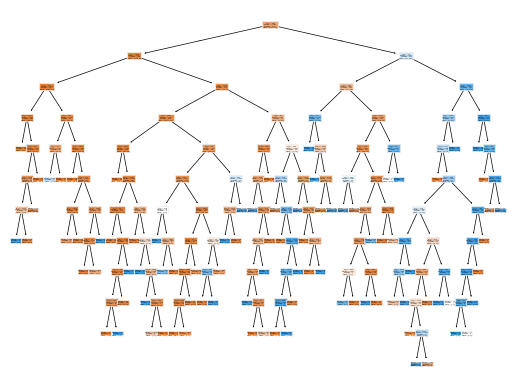

In [69]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier()
params = {
    "n_estimators": [10, 50, 100, 200], # núm. árboles a crear
    "criterion": ['gini', 'entropy', 'log_loss'], # función a minimizar
    'max_depth': [1, 3, 5, 10, 15],
    "min_samples_split": [2, 5, 10, 15, 20]
}
RF = get_best(RF, params, 5, train, y_train)
print(RF.score(train, y_train))
print(RF.score(test, y_test))
plot_tree(RF.estimators_[0], filled = True)

### Métricas

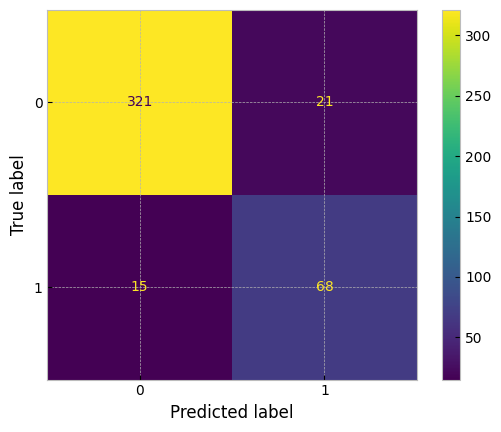

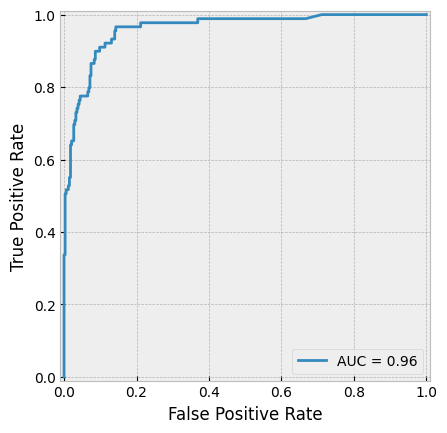

In [70]:
get_metricas(RF, test, y_test, [0,1])

# Gradient Boosting

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

1.0
0.9129411764705883


[Text(0.3254464285714286, 0.9545454545454546, 'x[2] <= 0.55\nfriedman_mse = 1.0\nsamples = 1697\nvalue = 0.0'),
 Text(0.09970238095238096, 0.8636363636363636, 'x[1] <= 59.5\nfriedman_mse = 1.103\nsamples = 300\nvalue = 1.233'),
 Text(0.21257440476190476, 0.9090909090909092, 'True  '),
 Text(0.047619047619047616, 0.7727272727272727, 'x[3] <= 61.0\nfriedman_mse = 1.124\nsamples = 56\nvalue = 0.102'),
 Text(0.04126984126984127, 0.6818181818181818, 'x[10] <= 1.498\nfriedman_mse = 0.956\nsamples = 52\nvalue = -0.032'),
 Text(0.025396825396825397, 0.5909090909090909, 'x[6] <= 103.0\nfriedman_mse = 0.577\nsamples = 44\nvalue = -0.267'),
 Text(0.012698412698412698, 0.5, 'x[10] <= 0.896\nfriedman_mse = 1.274\nsamples = 3\nvalue = 1.057'),
 Text(0.006349206349206349, 0.4090909090909091, 'friedman_mse = 0.0\nsamples = 1\nvalue = -1.0'),
 Text(0.01904761904761905, 0.4090909090909091, 'friedman_mse = 0.0\nsamples = 2\nvalue = 1.0'),
 Text(0.0380952380952381, 0.5, 'x[6] <= 135.5\nfriedman_mse = 0.38

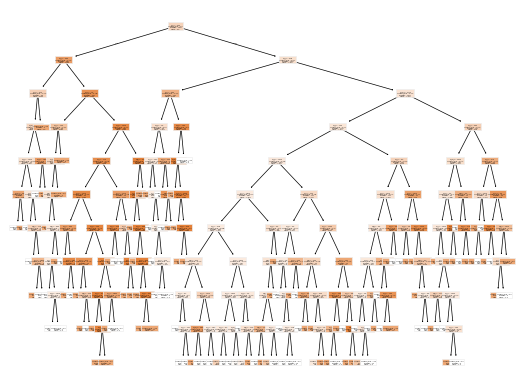

In [71]:
from sklearn.ensemble import GradientBoostingClassifier
GBC = GradientBoostingClassifier()
params = {
    "learning_rate": uniform(0, 100),
    "n_estimators": [1, 10, 25, 50, 100], # vigilar con overfitting
    "loss": ['log_loss', 'exponential'],
    "criterion": ['friedman_mse', 'squared_error'],
    "max_depth": [2, 5, 10]
}
GBC = get_best(GBC, params, 5, train, y_train)
print(GBC.score(train, y_train))
print(GBC.score(test, y_test))
plot_tree(GBC.estimators_[0,0], filled = True)

### Métricas

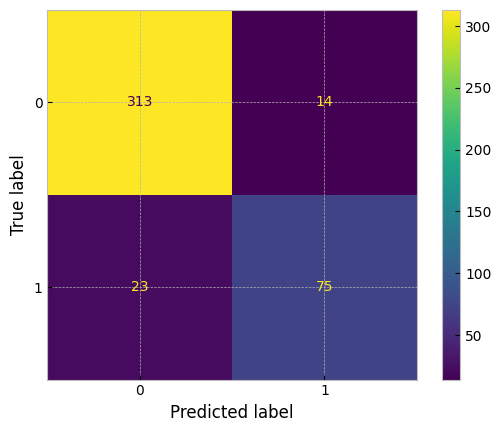

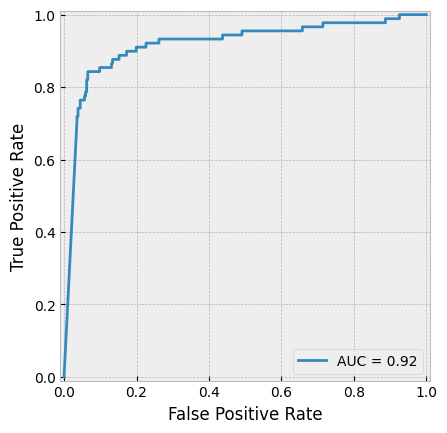

In [72]:
get_metricas(GBC, test, y_test, [0,1])

In [73]:
metricas

,algoritmo,accuracy,precision,recall,f1_score,auc
0,LogisticRegression,0.830357,0.830357,0.830357,0.830357,0.901201
1,MultinomialNB,0.680060,0.715302,0.598214,0.651540,0.680901
2,KNeighborsClassifier,0.846726,0.897611,0.782738,0.836248,0.846726
3,DecisionTreeClassifier,0.912941,0.817073,0.752809,0.783626,0.891804
4,SGDClassifier,0.751488,0.792388,0.681548,0.732800,0.846221
5,SVC,0.836310,0.889655,0.767857,0.824281,0.897552
6,RandomForestClassifier,0.915294,0.819277,0.764045,0.790698,0.960892
7,GradientBoostingClassifier,0.912941,0.765306,0.842697,0.802139,0.918539


# Aprendizaje supervisado automatizado (PyCaret)

In [74]:
pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.7 MB/s eta 0:00:00
   ━━━━━

In [17]:
from pycaret.classification import *

In [18]:
pipeline = setup(data=data, target='fetal_health', session_id=123)

,Description,Value
0,Session id,123
1,Target,fetal_health
2,Target type,Binary
3,Original data shape,"(2122, 13)"
4,Transformed data shape,"(2122, 13)"
5,Transformed train set shape,"(1485, 13)"
6,Transformed test set shape,"(637, 13)"
7,Numeric features,12
8,Preprocess,True
9,Imputation type,simple


In [19]:
best = compare_models(fold=5)
print(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9434,0.9662,0.8212,0.9156,0.8647,0.8291,0.8320,0.5340
xgboost,Extreme Gradient Boosting,0.9407,0.9636,0.8333,0.8954,0.8611,0.8236,0.8261,0.1140
rf,Random Forest Classifier,0.9354,0.9651,0.7909,0.9073,0.8441,0.8037,0.8074,0.3740
gbc,Gradient Boosting Classifier,0.9306,0.9600,0.7818,0.8938,0.8329,0.7895,0.7931,0.4780
et,Extra Trees Classifier,0.9273,0.9660,0.7697,0.8902,0.8241,0.7787,0.7830,0.2440
ada,Ada Boost Classifier,0.9077,0.9310,0.7606,0.8128,0.7848,0.7263,0.7277,0.1580
dt,Decision Tree Classifier,0.9051,0.8675,0.8000,0.7798,0.7891,0.7279,0.7285,0.0420
knn,K Neighbors Classifier,0.8781,0.9012,0.6545,0.7636,0.7043,0.6282,0.6315,0.0640
lr,Logistic Regression,0.8687,0.8937,0.5848,0.7680,0.6627,0.5833,0.5924,1.5100
lda,Linear Discriminant Analysis,0.8687,0.8939,0.5758,0.7755,0.6599,0.5809,0.5913,0.0400


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


Nos fijamos en el mejor algoritmo: lightgbm. Se trata de una variante del Gradient Boosting. \\
Entrenamos ahora nuestro modelo y ajustamos los hiperparámetros.

In [20]:
best = tune_model(best, fold=5)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9327,0.9577,0.7879,0.8966,0.8387,0.7964,0.7990
1,0.9226,0.9723,0.7273,0.9057,0.8067,0.7590,0.7662
2,0.9495,0.9792,0.8939,0.8806,0.8872,0.8547,0.8547
3,0.9360,0.9751,0.7424,0.9608,0.8376,0.7986,0.8089
4,0.9125,0.9172,0.7576,0.8333,0.7937,0.7383,0.7396
Mean,0.9306,0.9603,0.7818,0.8954,0.8328,0.7894,0.7937
Std,0.0125,0.0227,0.0595,0.0411,0.0323,0.0398,0.0392


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [21]:
best.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': -1,
 'num_leaves': 31,
 'objective': None,
 'random_state': 123,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [22]:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [23]:
predict_model(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9451,0.9665,0.8369,0.9077,0.8708,0.8360,0.8371


,baseline value,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_variance,histogram_tendency,fetal_health,prediction_label,prediction_score
1852,138.0,51.0,1.1,0.0,2.1,49.0,122.0,171.0,3.0,0.0,1.791759,0.0,0.0,0,0.9999
1865,138.0,49.0,1.6,0.0,5.7,92.0,80.0,172.0,5.0,0.0,3.091043,1.0,0.0,0,0.9999
947,142.0,34.0,1.1,0.0,19.6,67.0,94.0,161.0,5.0,1.0,2.079442,1.0,0.0,0,0.9994
1521,133.0,34.0,1.1,7.0,14.3,69.0,91.0,160.0,4.0,0.0,1.609438,0.0,0.0,0,0.9994
478,140.0,64.0,0.5,37.0,7.6,76.0,84.0,160.0,5.0,0.0,0.000000,1.0,1.0,1,0.9906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1650,114.0,65.0,0.5,0.0,12.0,24.0,102.0,126.0,1.0,0.0,0.000000,0.0,0.0,0,0.9932
1450,148.0,40.0,0.9,8.0,11.8,47.0,126.0,173.0,5.0,0.0,1.098612,0.0,0.0,0,0.7585
1935,133.0,62.0,2.2,0.0,0.5,48.0,97.0,145.0,2.0,0.0,2.397895,1.0,0.0,0,0.9978
883,136.0,45.0,0.6,48.0,4.3,19.0,135.0,154.0,2.0,0.0,0.000000,-1.0,0.0,0,0.9983
